In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import gsw
import colormaps as cmaps
import matplotlib.colors as mcolors
from tqdm import tqdm

In [2]:
## EN4 read vars

salt_EN4 = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/EN4_data/EN4_mergetime.nc').salinity.sel(time=slice('2004-01-01T00:00:00.000000000','2023-12-31T12:00:00.000000000'))
temp_EN4 = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/EN4_data/EN4_mergetime.nc').temperature.sel(time=slice('2004-01-01T00:00:00.000000000','2023-12-31T12:00:00.000000000')) - 273.15

## EN4 Compute vars

pressure_1d = gsw.conversions.p_from_z(-salt_EN4.depth,salt_EN4.latitude,geo_strf_dyn_height=0, sea_surface_geopotential=0)
pressure_np = np.tile(pressure_1d.values[None, :, :, None], (len(salt_EN4.time), 1, 1, len(salt_EN4.longitude)))
pressure = xr.DataArray(pressure_np,
coords={'time':salt_EN4.time, 'depth':salt_EN4.depth, 'latitude':salt_EN4.latitude, 'longitude':salt_EN4.longitude},
dims=["time", "depth", "latitude", "longitude"])
abs_salt_EN4 = gsw.conversions.SA_from_SP(salt_EN4, pressure, salt_EN4.longitude, salt_EN4.latitude)
cons_temp_EN4 = gsw.conversions.CT_from_pt(abs_salt_EN4, temp_EN4)
sig0_EN4 = gsw.density.sigma0(abs_salt_EN4, cons_temp_EN4)
alpha_EN4 = gsw.density.alpha(abs_salt_EN4, cons_temp_EN4, pressure_EN4)
beta_EN4 = gsw.density.beta(abs_salt_EN4, cons_temp_EN4, pressure_EN4)
# salt_EN4.to_netcdf('/scratch/kaushik/WORK/INTERMEDIATE_WATER/ENSEMBLE_MEANS/salt.nc')
# temp_EN4.to_netcdf('/scratch/kaushik/WORK/INTERMEDIATE_WATER/ENSEMBLE_MEANS/temp.nc')
abs_salt_EN4.to_netcdf('/scratch/kaushik/WORK/INTERMEDIATE_WATER/EN4_data/abs_salt.nc')
cons_temp_EN4.to_netcdf('/scratch/kaushik/WORK/INTERMEDIATE_WATER/EN4_data/cons_temp.nc')
sig0_EN4.to_netcdf('/scratch/kaushik/WORK/INTERMEDIATE_WATER/EN4_data/sig0.nc')
alpha_EN4.to_netcdf('/scratch/kaushik/WORK/INTERMEDIATE_WATER/EN4_data/alpha.nc')
beta_EN4.to_netcdf('/scratch/kaushik/WORK/INTERMEDIATE_WATER/EN4_data/beta.nc')

## Clean NB
%reset -f

## EN4 store vars

abs_salt_EN4 = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/EN4_data/abs_salt.nc').salinity.sel(time=slice('2004-01-01T00:00:00.000000000','2023-12-31T12:00:00.000000000'))
cons_temp_EN4 = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/EN4_data/cons_temp.nc').salinity.sel(time=slice('2004-01-01T00:00:00.000000000','2023-12-31T12:00:00.000000000'))
sig0_EN4 = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/EN4_data/sig0.nc').salinity.sel(time=slice('2004-01-01T00:00:00.000000000','2023-12-31T12:00:00.000000000'))
alpha_EN4 = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/EN4_data/alpha.nc').salinity.sel(time=slice('2004-01-01T00:00:00.000000000','2023-12-31T12:00:00.000000000'))
beta_EN4 = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/EN4_data/beta.nc').salinity.sel(time=slice('2004-01-01T00:00:00.000000000','2023-12-31T12:00:00.000000000'))

In [3]:
## IAP read vars

salt_IAP = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/ENSEMBLE_MEANS/salt_IAP_to_EN4.nc').salinity.sel(time=slice('200401,','202313'))
temp_IAP = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/ENSEMBLE_MEANS/temp_IAP_to_EN4.nc').temp.sel(time=slice('200401,','202313')) - 273.15

## IAP Compute vars

pressure_1d = gsw.conversions.p_from_z(-salt_IAP.depth,salt_IAP.latitude,geo_strf_dyn_height=0, sea_surface_geopotential=0)
pressure_np = np.tile(pressure_1d.values[None, :, :, None], (len(salt_IAP.time), 1, 1, len(salt_IAP.longitude)))
pressure = xr.DataArray(pressure_np,
coords={'time':salt_IAP.time, 'depth':salt_IAP.depth, 'latitude':salt_IAP.latitude, 'longitude':salt_IAP.longitude},
dims=["time", "depth", "latitude", "longitude"])
abs_salt_IAP = gsw.conversions.SA_from_SP(salt_IAP, pressure, salt_IAP.longitude, salt_IAP.latitude)
cons_temp_IAP = gsw.conversions.CT_from_pt(abs_salt_IAP, temp_IAP)
sig0_IAP = gsw.density.sigma0(abs_salt_IAP, cons_temp_IAP)
alpha_IAP = gsw.density.alpha(abs_salt_IAP, cons_temp_IAP, pressure_IAP)
beta_IAP = gsw.density.beta(abs_salt_IAP, cons_temp_IAP, pressure_IAP)
# salt_IAP.to_netcdf('/scratch/kaushik/WORK/INTERMEDIATE_WATER/IAP_data/salt.nc')
# temp_IAP.to_netcdf('/scratch/kaushik/WORK/INTERMEDIATE_WATER/IAP_data/temp.nc')
abs_salt_IAP.to_netcdf('/scratch/kaushik/WORK/INTERMEDIATE_WATER/IAP_data/abs_salt.nc')
cons_temp_IAP.to_netcdf('/scratch/kaushik/WORK/INTERMEDIATE_WATER/IAP_data/cons_temp.nc')
sig0_IAP.to_netcdf('/scratch/kaushik/WORK/INTERMEDIATE_WATER/IAP_data/sig0.nc')
alpha_IAP.to_netcdf('/scratch/kaushik/WORK/INTERMEDIATE_WATER/IAP_data/alpha.nc')
beta_IAP.to_netcdf('/scratch/kaushik/WORK/INTERMEDIATE_WATER/IAP_data/beta.nc')

## Clean NB
%reset -f

## IAP store vars

abs_salt_IAP = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/IAP_data/abs_salt.nc').salinity.sel(time=slice('2004-01-01T00:00:00.000000000','2023-12-31T12:00:00.000000000'))
cons_temp_IAP = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/IAP_data/cons_temp.nc').salinity.sel(time=slice('2004-01-01T00:00:00.000000000','2023-12-31T12:00:00.000000000'))
sig0_IAP = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/IAP_data/sig0.nc').salinity.sel(time=slice('2004-01-01T00:00:00.000000000','2023-12-31T12:00:00.000000000'))
alpha_IAP = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/IAP_data/alpha.nc').salinity.sel(time=slice('2004-01-01T00:00:00.000000000','2023-12-31T12:00:00.000000000'))
beta_IAP = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/IAP_data/beta.nc').salinity.sel(time=slice('2004-01-01T00:00:00.000000000','2023-12-31T12:00:00.000000000'))


In [4]:
## RG read vars

salt_RG = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/ENSEMBLE_MEANS/salt_RGARGO_to_EN4.nc').__xarray_dataarray_variable__.sel(time=slice('2004-01-01T00:00:00.000000000','2023-12-31T12:00:00.000000000'))
temp_RG = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/ENSEMBLE_MEANS/temp_RGARGO_to_EN4.nc').__xarray_dataarray_variable__.sel(time=slice('2004-01-01T00:00:00.000000000','2023-12-31T12:00:00.000000000'))

## RG Compute vars

depth_1d = gsw.conversions.z_from_p(salt_RG.pressure,salt_RG.latitude,geo_strf_dyn_height=0, sea_surface_geopotential=0)
depth_np = np.tile(depth_1d.values[None, :, :, None], (len(salt_RG.time), 1, 1, len(salt_RG.longitude)))
depth = xr.DataArray(depth_np,
coords={'time':salt_RG.time, 'depth':salt_RG.pressure, 'latitude':salt_RG.latitude, 'longitude':salt_RG.longitude},
dims=["time", "depth", "latitude", "longitude"])

salt_dp = salt_RG.assign_coords(pressure=depth_1d)
del salt_RG
salt_RG = salt_dp.rename({'pressure': 'depth'})

temp_dp = temp_RG.assign_coords(pressure=depth_1d)
del temp_RG
temp_RG = temp_dp.rename({'pressure': 'depth'})

abs_salt_RG = gsw.conversions.SA_from_SP(salt_RG, depth, salt_RG.longitude, salt_RG.latitude)
cons_temp_RG = gsw.conversions.CT_from_pt(abs_salt_RG, temp_RG)
sig0_RG = gsw.density.sigma0(abs_salt_RG, cons_temp_RG)
alpha_RG = gsw.density.alpha(abs_salt_RG, cons_temp_RG, pressure_RG)
beta_RG = gsw.density.beta(abs_salt_RG, cons_temp_RG, pressure_RG)
salt_RG.to_netcdf('/scratch/kaushik/WORK/INTERMEDIATE_WATER/RG_data/salt.nc')
temp_RG.to_netcdf('/scratch/kaushik/WORK/INTERMEDIATE_WATER/RG_data/temp.nc')
abs_salt_RG.to_netcdf('/scratch/kaushik/WORK/INTERMEDIATE_WATER/RG_data/abs_salt.nc')
cons_temp_RG.to_netcdf('/scratch/kaushik/WORK/INTERMEDIATE_WATER/RG_data/cons_temp.nc')
sig0_RG.to_netcdf('/scratch/kaushik/WORK/INTERMEDIATE_WATER/RG_data/sig0.nc')
alpha_RG.to_netcdf('/scratch/kaushik/WORK/INTERMEDIATE_WATER/RG_data/alpha.nc')
beta_RG.to_netcdf('/scratch/kaushik/WORK/INTERMEDIATE_WATER/RG_data/beta.nc')

## Clean NB
%reset -f

## RG store vars

abs_salt_RG = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/RG_data/abs_salt.nc').salinity.sel(time=slice('2004-01-01T00:00:00.000000000','2023-12-31T12:00:00.000000000'))
cons_temp_RG = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/RG_data/cons_temp.nc').salinity.sel(time=slice('2004-01-01T00:00:00.000000000','2023-12-31T12:00:00.000000000'))
sig0_RG = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/RG_data/sig0.nc').salinity.sel(time=slice('2004-01-01T00:00:00.000000000','2023-12-31T12:00:00.000000000'))
alpha_RG = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/RG_data/alpha.nc').salinity.sel(time=slice('2004-01-01T00:00:00.000000000','2023-12-31T12:00:00.000000000'))
beta_RG = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/RG_data/beta.nc').salinity.sel(time=slice('2004-01-01T00:00:00.000000000','2023-12-31T12:00:00.000000000'))

In [5]:
salt_ENS = (salt_EN4 + salt_IAP + salt_RG)/3
temp_ENS = (temp_EN4 + temp_IAP + temp_RG)/3
abs_salt_ENS = (abs_salt_EN4 + abs_salt_IAP + abs_salt_RG)/3
cons_temp_ENS = (cons_temp_EN4 + cons_temp_IAP + cons_temp_RG)/3
sig0_ENS = (sig0_EN4 + sig0_IAP + sig0_RG)/3
alpha_ENS = (alpha_EN4 + alpha_IAP + alpha_RG)/3
beta_ENS = (beta_EN4 + beta_IAP + beta_RG)/3

salt_ENS.to_netcdf('/scratch/kaushik/WORK/INTERMEDIATE_WATER/ENSEMBLE_MEANS/salt_IAP_EN4_RG_mean.nc')
temp_ENS.to_netcdf('/scratch/kaushik/WORK/INTERMEDIATE_WATER/ENSEMBLE_MEANS/temp_IAP_EN4_RG_mean.nc')
abs_salt_ENS.to_netcdf('/scratch/kaushik/WORK/INTERMEDIATE_WATER/ENSEMBLE_MEANS/abs_salt_IAP_EN4_RG_mean.nc')
cons_temp_ENS.to_netcdf('/scratch/kaushik/WORK/INTERMEDIATE_WATER/ENSEMBLE_MEANS/cons_temp_IAP_EN4_RG_mean.nc')
sig0_ENS.to_netcdf('/scratch/kaushik/WORK/INTERMEDIATE_WATER/ENSEMBLE_MEANS/sig0_IAP_EN4_RG_mean.nc')
alpha_ENS.to_netcdf('/scratch/kaushik/WORK/INTERMEDIATE_WATER/ENSEMBLE_MEANS/alpha_IAP_EN4_RG_mean.nc')
beta_ENS.to_netcdf('/scratch/kaushik/WORK/INTERMEDIATE_WATER/ENSEMBLE_MEANS/beta_IAP_EN4_RG_mean.nc')

In [6]:
salt = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/ENSEMBLE_MEANS/salt_IAP_EN4_mean.nc').salinity.sel(time=slice('2004-01-01T00:00:00.000000000','2023-12-31T12:00:00.000000000'))
temp = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/ENSEMBLE_MEANS/temp_IAP_EN4_mean.nc').__xarray_dataarray_variable__.sel(time=slice('2004-01-01T00:00:00.000000000','2023-12-31T12:00:00.000000000')) - 273.15
abs_salt = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/ENSEMBLE_MEANS/abs_salt_IAP_EN4_mean.nc').salinity.sel(time=slice('2004-01-01T00:00:00.000000000','2023-12-31T12:00:00.000000000'))
cons_temp = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/ENSEMBLE_MEANS/cons_temp_IAP_EN4_mean.nc').salinity.sel(time=slice('2004-01-01T00:00:00.000000000','2023-12-31T12:00:00.000000000'))
sig0 = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/ENSEMBLE_MEANS/sig0_IAP_EN4_mean.nc').salinity.sel(time=slice('2004-01-01T00:00:00.000000000','2023-12-31T12:00:00.000000000'))
alpha = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/ENSEMBLE_MEANS/alpha_IAP_EN4_mean.nc').salinity.sel(time=slice('2004-01-01T00:00:00.000000000','2023-12-31T12:00:00.000000000'))
beta = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/ENSEMBLE_MEANS/beta_IAP_EN4_mean.nc').salinity.sel(time=slice('2004-01-01T00:00:00.000000000','2023-12-31T12:00:00.000000000'))
mld = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/EN4_data/mld_en4.nc').mlotst.sel(time=slice('2004-01-01T00:00:00.000000000','2023-12-31T12:00:00.000000000'))
mld['time'] = salt.time

def compute_mld(sig0,
                ref_depth,
                delta_sigma,
                depth_dim):
    depth = sig0[depth_dim]
    sig_ref = sig0.sel({depth_dim: ref_depth}, method='nearest')
    delta = sig0 - sig_ref
    meets = delta >= delta_sigma
    idx = meets.argmax(dim=depth_dim)
    any_true = meets.any(dim=depth_dim)
    sig_i = sig0.isel({depth_dim: idx})
    sig_im1 = sig0.isel({depth_dim: idx-1})
    delta_i = sig_i - sig_ref
    delta_im1 = sig_im1 - sig_ref
    z_i = depth.isel({depth_dim: idx})
    z_im1 = depth.isel({depth_dim: idx-1})
    frac = (delta_sigma - delta_im1) / (delta_i - delta_im1)
    mld_interp = z_im1 + frac * (z_i - z_im1)
    mld = mld_interp.where(any_true)
    mld = xr.where(idx == 0, z_i, mld)
    mld.name = "MLD"
    mld.attrs['units'] = getattr(depth, "units", "m")
    mld.attrs['description'] = (
        f"Interpolated MLD where sigma0(z) - sigma0({ref_depth}m) >= {delta_sigma} kg/m3"
    )
    return mld

mld = compute_mld(sig0,ref_depth=10,delta_sigma=0.03,depth_dim='depth')

In [7]:
mld

<xarray.DataArray 'MLD' (time: 240, lat: 173, lon: 360)> Size: 120MB
array([[[ 5.02158976,  5.02158976,  5.02158976, ...,  5.02158976,
          5.02158976,  5.02158976],
        [ 5.02158976,  5.02158976,  5.02158976, ...,  5.02158976,
          5.02158976,  5.02158976],
        [ 5.02158976,  5.02158976,  5.02158976, ...,  5.02158976,
          5.02158976,  5.02158976],
        ...,
        [16.58347863, 16.57214322, 16.57465187, ..., 16.89346471,
         16.83747662, 16.8463041 ],
        [27.10931967, 27.04225772, 27.09264187, ..., 27.28717278,
         27.39130722, 27.45466964],
        [39.47832901, 39.59675994, 39.73679287, ..., 38.2726843 ,
         38.54917449, 38.81727941]],

       [[ 5.02158976,  5.02158976,  5.02158976, ...,  5.02158976,
          5.02158976,  5.02158976],
        [ 5.02158976,  5.02158976,  5.02158976, ...,  5.02158976,
          5.02158976,  5.02158976],
        [ 5.02158976,  5.02158976,  5.02158976, ...,  5.02158976,
          5.02158976,  5.02158976],
...
        [11.09228806, 10.99763252, 11.26351915, ..., 11.43452271,
         11.31747247, 11.28994012],
        [29.92845004, 30.02752115, 30.18501338, ..., 29.30113925,
         29.41321596, 29.58397034],
        [28.11234017, 28.29071481, 28.50334383, ..., 27.43297653,
         27.59812852, 27.83374139]],

       [[ 5.02158976,  5.02158976,  5.02158976, ...,  5.02158976,
          5.02158976,  5.02158976],
        [ 5.02158976,  5.02158976,  5.02158976, ...,  5.02158976,
          5.02158976,  5.02158976],
        [ 5.02158976,  5.02158976,  5.02158976, ...,  5.02158976,
          5.02158976,  5.02158976],
        ...,
        [11.65918469, 11.96547138, 12.59118151, ..., 11.16981947,
         11.30546702, 11.57272732],
        [38.70210025, 38.80125104, 38.93105722, ..., 37.41006142,
         37.73568201, 37.98028581],
        [38.70218744, 38.8749993 , 39.07133512, ..., 37.20698323,
         37.60393285, 37.92484008]]])
Coordinates:
  * time     (time) datetime64[ns] 2kB 2004-01-16T12:00:00 ... 2023-12-16T12:...
  * lon      (lon) float32 1kB 1.0 2.0 3.0 4.0 5.0 ... 357.0 358.0 359.0 360.0
  * lat      (lat) float32 692B -83.0 -82.0 -81.0 -80.0 ... 86.0 87.0 88.0 89.0
Attributes:
    units:        metres
    description:  Interpolated MLD where sigma0(z) - sigma0(10m) >= 0.03 kg/m3

In [8]:
pf_lats = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/ACC_fronts/62985.nc').LatPF
pf_lons = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/ACC_fronts/62985.nc').LonPF

In [9]:
### CALCULATE DEPTH OF DEISTY ISOSURFACE


def isosurface(field, target, dim):
    """
    Linearly interpolate a coordinate isosurface where a field
    equals a target

    Parameters
    ----------
    field : xarray DataArray
        The field in which to interpolate the target isosurface
    target : float
        The target isosurface value
    dim : str
        The field dimension to interpolate

    Examples
    --------
    Calculate the depth of an isotherm with a value of 5.5:

    >>> temp = xr.DataArray(
    ...     range(10,0,-1),
    ...     coords={"depth": range(10)}
    ... )
    >>> isosurface(temp, 5.5, dim="depth")
    <xarray.DataArray ()>
    array(4.5)
    """
    slice0 = {dim: slice(None, -1)}
    slice1 = {dim: slice(1, None)}

    field0 = field.isel(slice0).drop(dim)
    field1 = field.isel(slice1).drop(dim)

    crossing_mask_decr = (field0 > target) & (field1 <= target)
    crossing_mask_incr = (field0 < target) & (field1 >= target)
    crossing_mask = xr.where(
        crossing_mask_decr | crossing_mask_incr, 1, np.nan
    )

    coords0 = crossing_mask * field[dim].isel(slice0).drop(dim)
    coords1 = crossing_mask * field[dim].isel(slice1).drop(dim)
    field0 = crossing_mask * field0
    field1 = crossing_mask * field1

    iso = (
        coords0 + (target - field0) *
        (coords1 - coords0) / (field1 - field0)
    )

    return iso.max(dim, skipna=True)

In [10]:
from xgcm import Grid
import xarray as xr
import numpy as np

N_t_sqr = -(9.81/1025)*alpha*np.gradient(cons_temp, abs_salt.depth, axis=1)
N_s_sqr = (9.81/1025)*beta*np.gradient(abs_salt, abs_salt.depth, axis=1)
N_sqr_calc = (9.81/1025)*np.gradient(sig0, sig0.depth, axis=1) * (N_s_sqr*0+1)

# sal_up = xr.where(sig0<=26.93,np.nan,abs_salt)
# sal_bn = xr.where(sig0>=27.53,np.nan,sal_up)

vol_34p6_bool =  abs_salt*0

for i in tqdm(range(0, 173), desc="Computing 34.6 PSU mask"):
    if (vol_34p6_bool[:,:,i,:].lat < 90) & (vol_34p6_bool[:,:,i,:].lat > -90):
        vol_34p6_bool[:,:,i,:] = xr.where(abs_salt[:,:,i,:]<=34.6, 1, np.nan)
    else:
        vol_34p6_bool[:,:,i,:] = np.nan
        
dsdz = N_s_sqr*vol_34p6_bool
salt_34p6 = abs_salt*vol_34p6_bool
dsdz_depth = isosurface(dsdz,0,'depth')

results = []
for t in tqdm(range(0,240), desc="Computing salt_along_dsdz"):
    part = salt_34p6.isel(time=t).interp(
        depth=dsdz_depth.isel(time=t),
        method="linear"
    )
    results.append(part)
salt_along_dsdz = xr.concat(results, dim='time')
del results

results = []
for t in tqdm(range(0,240), desc="Computing temp_along_dsdz"):
    part = cons_temp.isel(time=t).interp(
        depth=dsdz_depth.isel(time=t),
        method="linear"
    )
    results.append(part)
temp_along_dsdz = xr.concat(results, dim='time')
del results

results = []
for t in tqdm(range(0,240), desc="Computing sig0_along_dsdz"):
    part = sig0.isel(time=t).interp(
        depth=dsdz_depth.isel(time=t),
        method="linear"
    )
    results.append(part)
sig0_along_dsdz = xr.concat(results, dim='time')
del results

results = []
for t in tqdm(range(0,240), desc="Computing N_sqr_along_dsdz"):
    part = N_sqr_calc.isel(time=t).interp(
        depth=dsdz_depth.isel(time=t),
        method="linear"
    )
    results.append(part)
N_sqr_along_dsdz = xr.concat(results, dim='time')
del results

results = []
for t in tqdm(range(0,240), desc="Computing N_t_sqr_along_dsdz"):
    part = N_t_sqr.isel(time=t).interp(
        depth=dsdz_depth.isel(time=t),
        method="linear"
    )
    results.append(part)
N_t_sqr_along_dsdz = xr.concat(results, dim='time')
del results

results = []
for t in tqdm(range(0,240), desc="Computing alpha_along_dsdz"):
    part = alpha.isel(time=t).interp(
        depth=dsdz_depth.isel(time=t),
        method="linear"
    )
    results.append(part)
alpha_along_dsdz = xr.concat(results, dim='time')
del results

results = []
for t in tqdm(range(0,240), desc="Computing beta_along_dsdz"):
    part = beta.isel(time=t).interp(
        depth=dsdz_depth.isel(time=t),
        method="linear"
    )
    results.append(part)
beta_along_dsdz = xr.concat(results, dim='time')
del results

top_aaiw = isosurface(sig0, 26.93, 'depth')
bot_aaiw = isosurface(sig0, 27.53, 'depth')
aaiw_thick = bot_aaiw - top_aaiw

Computing 34.6 PSU mask: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 173/173 [00:02<00:00, 64.31it/s]
/tmp/ipykernel_407260/1113764205.py:33: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  field0 = field.isel(slice0).drop(dim)
/tmp/ipykernel_407260/1113764205.py:34: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  field1 = field.isel(slice1).drop(dim)
/tmp/ipykernel_407260/1113764205.py:42: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  coords0 = crossing_mask * field[dim].isel(slice0).drop(dim)
/tmp/ipykernel_407260/1113764205.py:43: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  coords1 = crossing_mask * field[dim].isel(slice1).drop(dim)
Computing beta_along_dsdz: 100%|███████████████████████████████████████████████████████████████████████████████████████████| 240/240 [00:03<00:00, 64.

In [11]:
import numpy as np
from scipy.interpolate import interp1d

# Ensure PF longitudes are wrapped consistently with EN4 (e.g., 0 to 360)
pf_lons_wrapped = np.mod(pf_lons, 360)
# lon_en4_wrapped = np.mod(lon_en4, 360)

pf_interp = interp1d(pf_lons_wrapped, pf_lats, kind='linear', bounds_error=False, fill_value='extrapolate')
pf_lat_on_en4 = pf_interp(abs_salt.lon.values)
LAT, LON = np.meshgrid(abs_salt.lat.values, abs_salt.lon.values, indexing='ij')
pf_lat_2d = np.tile(pf_lat_on_en4, (LAT.shape[0], 1))
south_of_pf_mask = LAT <= pf_lat_2d

filler = dsdz_depth[:,:] * (cons_temp[0,0,:,:]*0 + 1)
dsdz_depth_masked_northPF = filler.where(~south_of_pf_mask)  # ~ to invert the mask

filler = salt_along_dsdz[:,:] * (cons_temp[0,0,:,:]*0 + 1)
salt_masked_northPF = filler.where(~south_of_pf_mask)  # ~ to invert the mask

filler = temp_along_dsdz[:,:] * (cons_temp[0,0,:,:]*0 + 1)
temp_masked_northPF = filler.where(~south_of_pf_mask)  # ~ to invert the mask

filler = sig0_along_dsdz[:,:] * (cons_temp[0,0,:,:]*0 + 1)
sig0_masked_northPF = filler.where(~south_of_pf_mask)  # ~ to invert the mask

filler = N_sqr_along_dsdz[:,:] * (cons_temp[0,0,:,:]*0 + 1)
N_sqr_masked_northPF = filler.where(~south_of_pf_mask)  # ~ to invert the mask

filler = aaiw_thick[:,:] * (cons_temp[0,0,:,:]*0 + 1)
aaiw_thick_northPF = filler.where(~south_of_pf_mask)  # ~ to invert the mask

filler = top_aaiw[:,:] * (cons_temp[0,0,:,:]*0 + 1)
top_aaiw_northPF = filler.where(~south_of_pf_mask)  # ~ to invert the mask

filler = bot_aaiw[:,:] * (cons_temp[0,0,:,:]*0 + 1)
bot_aaiw_northPF = filler.where(~south_of_pf_mask)  # ~ to invert the mask

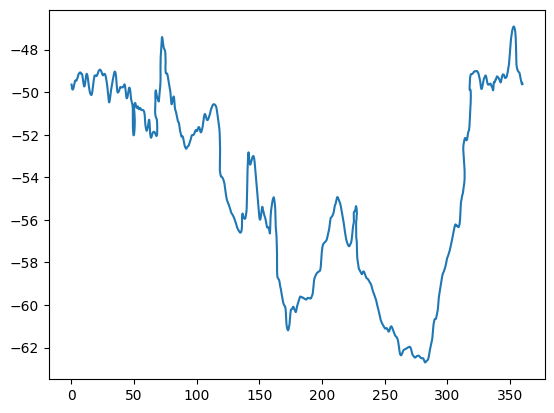

In [12]:
pf_lats = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/ACC_fronts/62985.nc').LatPF
pf_lons = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/ACC_fronts/62985.nc').LonPF

plt.plot(np.mod(pf_lons, 360),pf_lats)

import numpy as np
from scipy.interpolate import interp1d

# Ensure PF longitudes are wrapped consistently with EN4 (e.g., 0 to 360)
pf_lons_wrapped = np.mod(pf_lons, 360)
# lon_en4_wrapped = np.mod(lon_en4, 360)

pf_interp = interp1d(pf_lons_wrapped, pf_lats, kind='linear', bounds_error=False, fill_value='extrapolate')
pf_lat_on_en4 = pf_interp(abs_salt.lon.values)
LAT, LON = np.meshgrid(abs_salt.lat.values, abs_salt.lon.values, indexing='ij')
pf_lat_2d = np.tile(pf_lat_on_en4, (LAT.shape[0], 1))
south_of_pf_mask = LAT >= pf_lat_2d

filler = abs_salt
abs_salt_masked = filler.where(~south_of_pf_mask)  # ~ to invert the mask

filler = cons_temp
cons_temp_masked = filler.where(~south_of_pf_mask)  # ~ to invert the mask

filler = sig0
sig0_masked = filler.where(~south_of_pf_mask)  # ~ to invert the mask

filler = mld
mld_masked = filler.where(~south_of_pf_mask)  # ~ to invert the mask

filler = N_t_sqr
N_t_sqr_masked = filler.where(~south_of_pf_mask)  # ~ to invert the mask

filler = N_s_sqr
N_s_sqr_masked = filler.where(~south_of_pf_mask)  # ~ to invert the mask

filler = N_sqr_calc
N_sqr_masked = filler.where(~south_of_pf_mask)  # ~ to invert the mask

filler = alpha
alpha_masked = filler.where(~south_of_pf_mask)  # ~ to invert the mask

filler = beta
beta_masked = filler.where(~south_of_pf_mask)  # ~ to invert the mask

PF_lats = xr.DataArray(pf_lat_2d[0,:],
coords={'lon': mld.lon},
dims=["lon"])

In [13]:
mld_mask = xr.where(cons_temp.depth>=mld,1,np.nan)

cons_temp_mld_mask = cons_temp_masked*mld_mask
N_t_sqr_mld_mask = N_t_sqr_masked*mld_mask
abs_salt_mld_mask = abs_salt_masked*mld_mask
N_s_sqr_mld_mask = N_s_sqr_masked*mld_mask
sig0_mld_mask = sig0_masked*mld_mask
N_sqr_mld_mask = N_sqr_masked*mld_mask
alpha_mld_mask = alpha_masked*mld_mask
beta_mld_mask = beta_masked*mld_mask

N_t_sqr_grad_np = np.gradient(N_t_sqr_mld_mask,N_t_sqr_masked.depth,axis=1)
N_t_sqr_grad = xr.DataArray(N_t_sqr_grad_np,
coords={'time':N_t_sqr_masked.time, 'depth':N_t_sqr_masked.depth, 'lat': N_t_sqr_masked.lat,'lon': N_t_sqr_masked.lon},
dims=["time", "depth", "lat", "lon"])

import xarray as xr
min_temp_idx = cons_temp_mld_mask.sel(depth=slice(0,300)).idxmin(dim='depth')
depths = cons_temp_mld_mask['depth']
min_temp_depth = min_temp_idx

import xarray as xr
WW_bot_idx = N_t_sqr_mld_mask.sel(depth=slice(0,300)).idxmin(dim='depth')
# depths = WW_bot_depth_mask['depth']
WW_bot_depth = WW_bot_idx

top_ww = mld
bot_ww = WW_bot_depth
ww_thick = bot_ww-mld

results = []
for t in tqdm(range(0,240), desc="Computing salt_along_tmin"):
    part = abs_salt_mld_mask.isel(time=t).interp(
        depth=min_temp_depth.isel(time=t),
        method="linear"
    )
    results.append(part)
salt_along_tmin = xr.concat(results, dim='time')
del results

results = []
for t in tqdm(range(0,240), desc="Computing temp_along_tmin"):
    part = cons_temp_mld_mask.isel(time=t).interp(
        depth=min_temp_depth.isel(time=t),
        method="linear"
    )
    results.append(part)
temp_along_tmin = xr.concat(results, dim='time')
del results

results = []
for t in tqdm(range(0,240), desc="Computing sig0_along_tmin"):
    part = sig0_mld_mask.isel(time=t).interp(
        depth=min_temp_depth.isel(time=t),
        method="linear"
    )
    results.append(part)
sig0_along_tmin = xr.concat(results, dim='time')
del results

results = []
for t in tqdm(range(0,240), desc="Computing N_sqr_along_tmin"):
    part = N_sqr_mld_mask.isel(time=t).interp(
        depth=min_temp_depth.isel(time=t),
        method="linear"
    )
    results.append(part)
N_sqr_along_tmin = xr.concat(results, dim='time')
del results

results = []
for t in tqdm(range(0,240), desc="Computing N_t_sqr_along_tmin"):
    part = N_t_sqr_mld_mask.isel(time=t).interp(
        depth=min_temp_depth.isel(time=t),
        method="linear"
    )
    results.append(part)
N_t_sqr_along_tmin = xr.concat(results, dim='time')
del results

results = []
for t in tqdm(range(0,240), desc="Computing N_s_sqr_along_tmin"):
    part = N_s_sqr_mld_mask.isel(time=t).interp(
        depth=min_temp_depth.isel(time=t),
        method="linear"
    )
    results.append(part)
N_s_sqr_along_tmin = xr.concat(results, dim='time')
del results

results = []
for t in tqdm(range(0,240), desc="Computing alpha_along_tmin"):
    part = alpha_mld_mask.isel(time=t).interp(
        depth=min_temp_depth.isel(time=t),
        method="linear"
    )
    results.append(part)
alpha_along_tmin = xr.concat(results, dim='time')
del results

results = []
for t in tqdm(range(0,240), desc="Computing beta_along_tmin"):
    part = beta_mld_mask.isel(time=t).interp(
        depth=min_temp_depth.isel(time=t),
        method="linear"
    )
    results.append(part)
beta_along_tmin = xr.concat(results, dim='time')
del results

Computing beta_along_tmin: 100%|███████████████████████████████████████████████████████████████████████████████████████████| 240/240 [00:03<00:00, 65.69it/s]


/scratch/kaushik/anaconda3/envs/ocean_old/lib/python3.11/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)


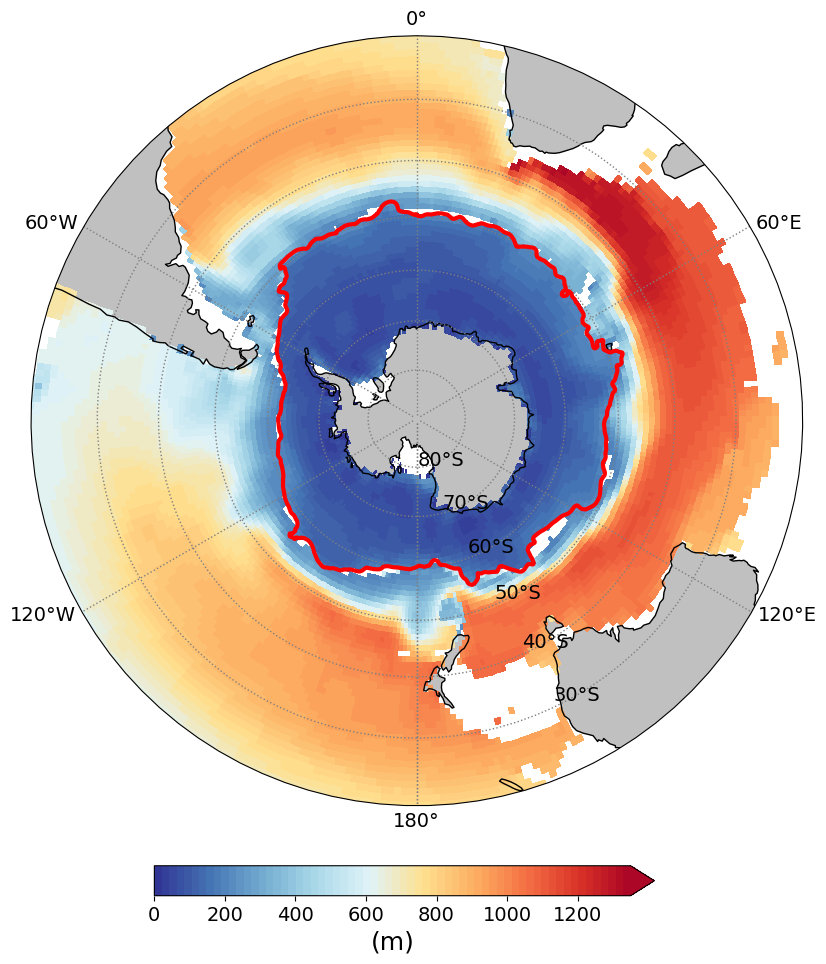

In [12]:
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

dsdz_depth_masked_mod = xr.where(dsdz_depth_masked_northPF<=200,np.nan,dsdz_depth_masked_northPF)
comb_aaiw_ww_depths_clim = dsdz_depth_masked_mod.fillna(0) + min_temp_depth.fillna(0)
comb_aaiw_ww_depths_clim = xr.where(comb_aaiw_ww_depths_clim==0,np.nan,comb_aaiw_ww_depths_clim)

def polarCentral_set_latlim(lat_lims, ax):
    ax.set_extent([-180, 180, lat_lims[0], lat_lims[1]], ccrs.PlateCarree())
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1,1,1, projection=ccrs.SouthPolarStereo(central_longitude=0))
ax.add_feature(cfeature.LAND, facecolor='silver')
ax.coastlines(linewidth=1, color='k')

gl = ax.gridlines(color='C7', lw=1, ls=':', draw_labels=True, rotate_labels=False,
                  ylocs=[-80, -70, -60, -50, -40, -30], xlocs=[-180, -120, -60, 0, 60, 120, 180])
gl.xlabel_style = {'size': 14}
gl.ylabel_style = {'size': 14}

filler = comb_aaiw_ww_depths_clim.mean('time').values
lon = cons_temp['lon'].values
lat = cons_temp['lat'].values

filler[:, -3:] = filler[:, -4:-3]
filler[:, 0:3] = filler[:, 2:3]

lon_fixed = np.append(lon, lon[0] + 360)
filler_fixed = np.hstack([filler, filler[:, 0:1]])

cs1 = ax.pcolormesh(lon_fixed, lat, filler_fixed,
                    cmap=cmaps.cmp_b2r, vmin=0, vmax=1350,
                    transform=ccrs.PlateCarree(), zorder=1)

cbar_ax = fig.add_axes([0.25, 0.02, 0.5, 0.03])
cbar1 = fig.colorbar(cs1, cax=cbar_ax, orientation='horizontal', extend='max')
cbar1.set_label(r'(m)', size=18)
cbar1.ax.tick_params(labelsize=14)

pf_lons_wrapped = np.mod(pf_lons, 360)
ax.plot(pf_lons_wrapped, pf_lats, color='red', linewidth=3, transform=ccrs.PlateCarree(), zorder=2)

polarCentral_set_latlim((-90,-20), ax)
# plt.show
# plt.savefig('/scratch/kaushik/WORK/INTERMEDIATE_WATER/my_py_scripts/figures/ENSEMBLE_MEANS/final_figure_nc_files/final_nc_files/Fig_1_cores.jpg',bbox_inches='tight', dpi=1000)

/tmp/ipykernel_407260/1213674440.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 1])


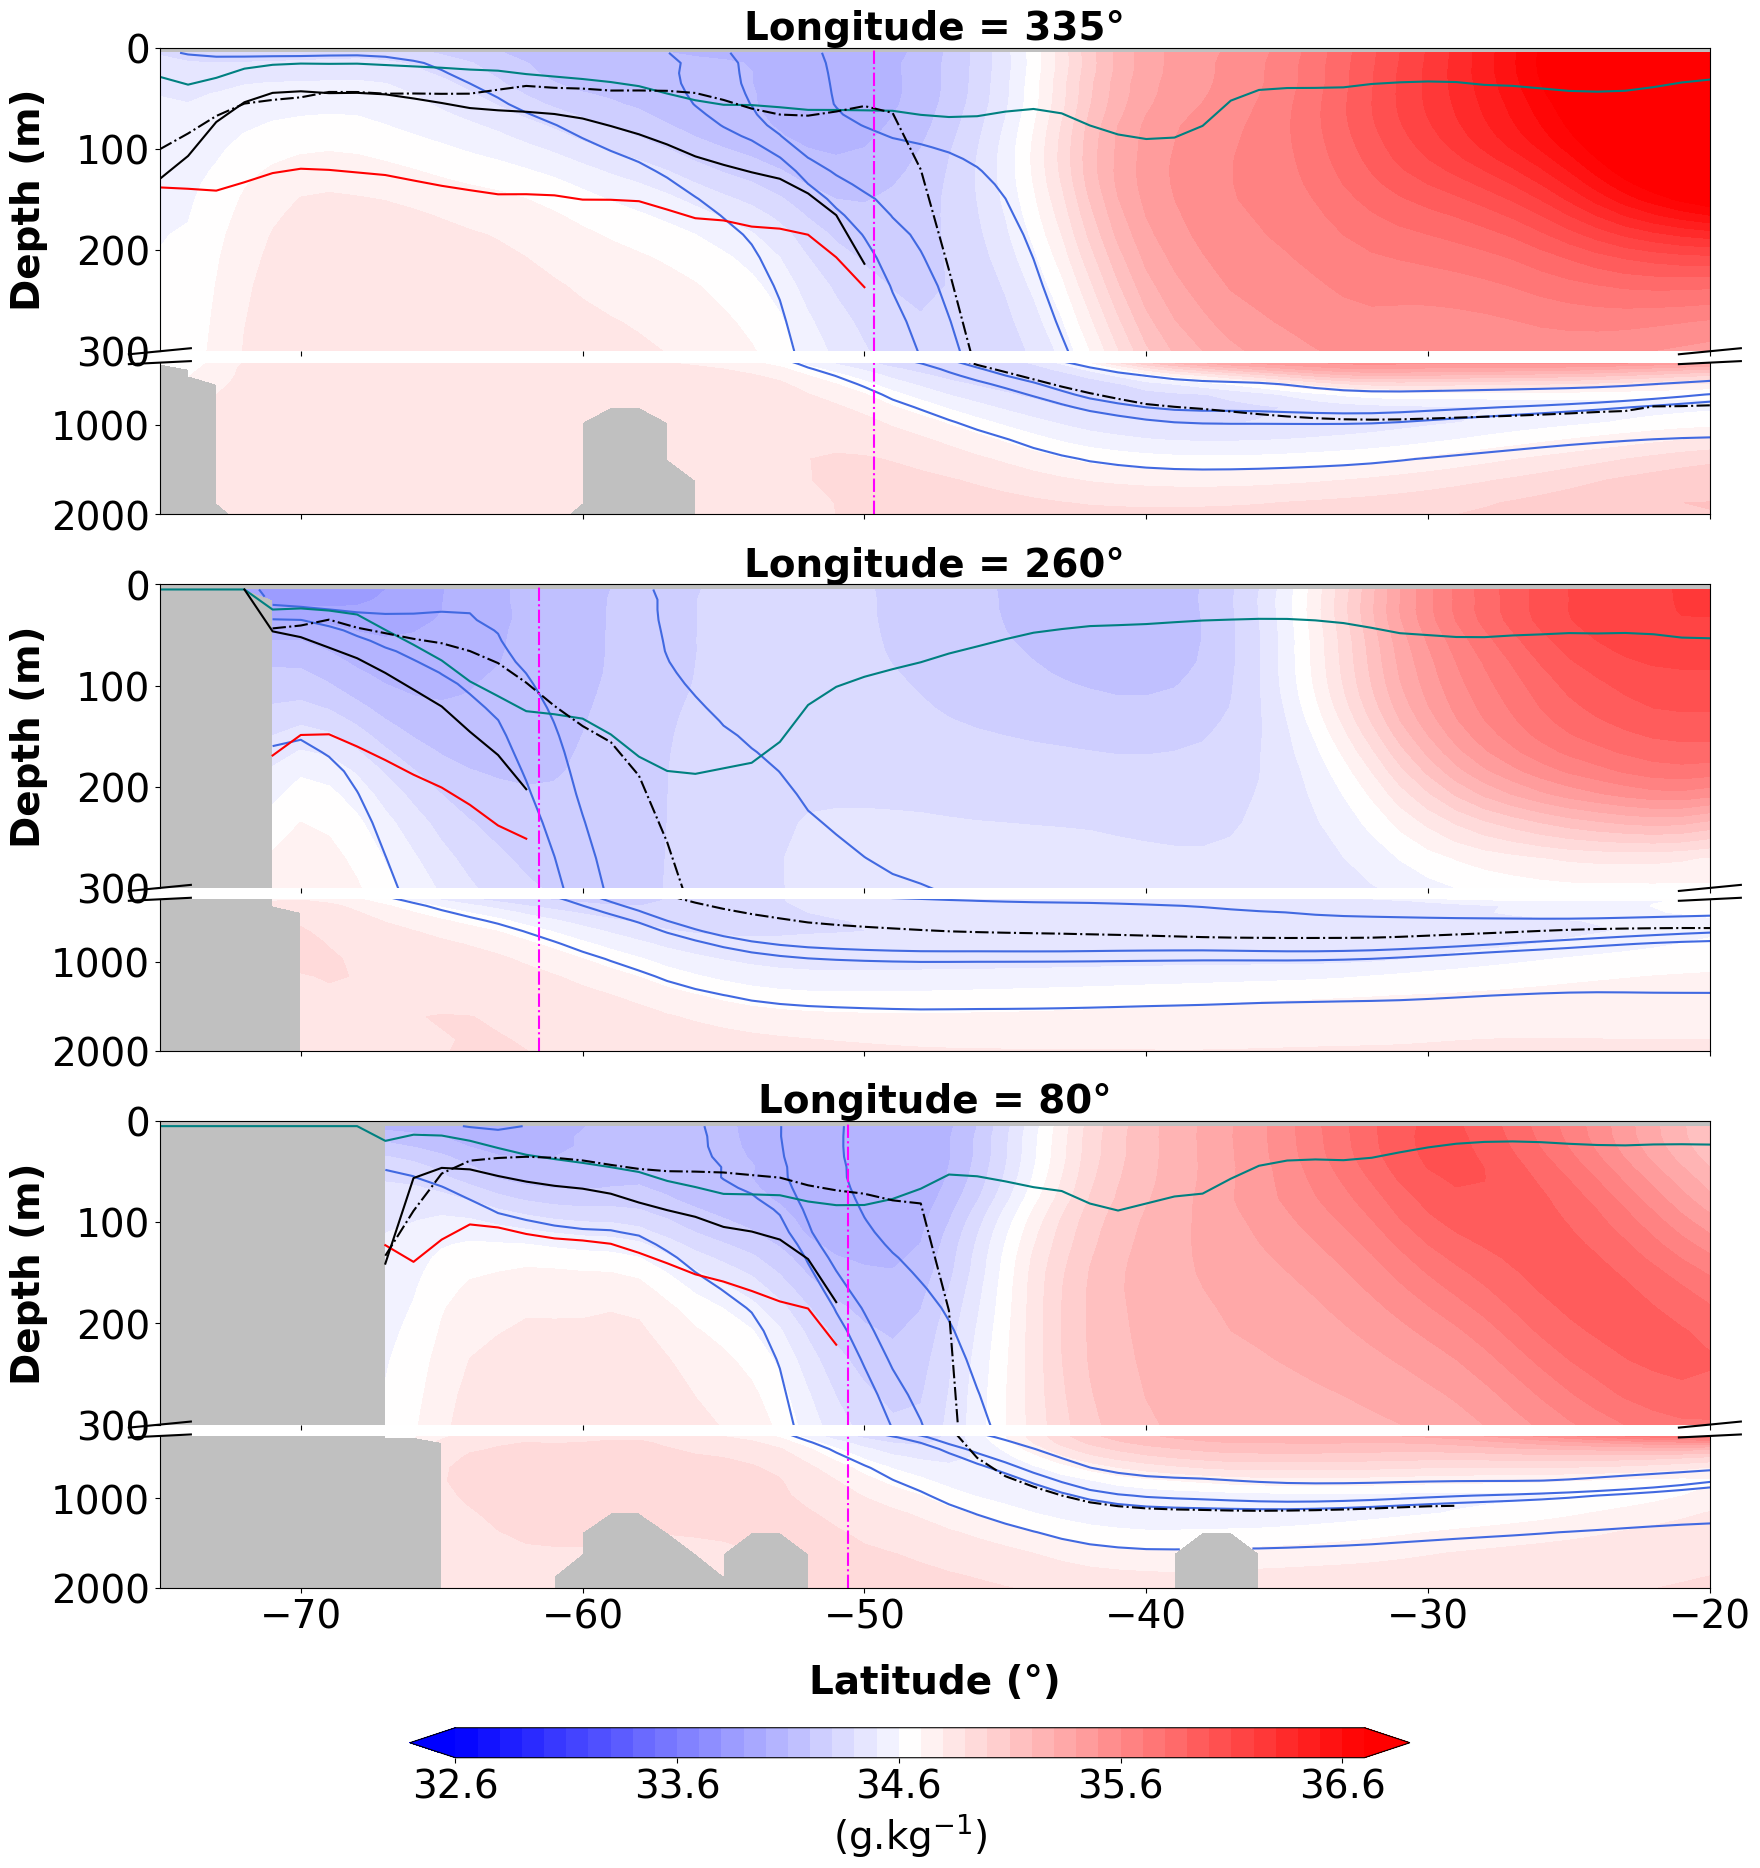

In [14]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import numpy as np

# Longitudes for the three panels
lons = [335, 260, 80]

fig = plt.figure(figsize=(20, 20))  # Increase height for 3 stacked figures
outer_gs = gridspec.GridSpec(3, 1, height_ratios=[1, 1, 1], hspace=0.15)  # Three rows for three longitudes

for i, lon in enumerate(lons):
    # Inner GridSpec for each longitude: two rows (upper & lower depth)
    inner_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[i], height_ratios=[2, 1], hspace=0.05)

    # --- First subplot (shallow) ---
    ax1 = plt.subplot(inner_gs[0])
    cf1 = ax1.contourf(abs_salt['lat'], abs_salt['depth'],
                       abs_salt.sel(lon=lon, method='nearest').mean('time'),
                       np.arange(32.6, 36.7, 0.1), cmap='bwr', extend='both')

    ax1.contour(mld_mask['lat'], mld_mask['depth'],
                sig0.sel(lon=lon, method='nearest').mean('time'),
                levels=[26.93, 27.15, 27.23, 27.53, 28], colors='royalblue')
    ax1.plot(mld['lat'], mld.sel(lon=lon, method='nearest').mean('time'), color='teal')
    ax1.plot(mld['lat'], min_temp_depth.sel(lon=lon, method='nearest').mean('time'), color='black')
    ax1.plot(mld['lat'], WW_bot_depth.sel(lon=lon, method='nearest').mean('time'), color='red')
    ax1.plot(mld.sel(lat=slice(-80, -20))['lat'],
             dsdz_depth.sel(lon=lon, method='nearest').sel(lat=slice(-80, -20)).mean('time'),
             linestyle='-.', color='black')
    ax1.axvline(PF_lats.sel(lon=lon, method='nearest'), linestyle='-.', color='magenta')

    ax1.set_ylim(300, 0)
    ax1.set_xlim(-75, -20)
    ax1.spines['bottom'].set_visible(False)
    ax1.tick_params(labelbottom=False, labelsize=28)  # Remove x-ticks
    ax1.set_title(f'Longitude = {lon}°', fontsize=28, fontweight='bold')
    ax1.set_ylabel('Depth (m)', fontsize=28, fontweight='bold', labelpad=20)  # ✅ Added y-label
    ax1.set_facecolor('silver')

    # --- Second subplot (deep) ---
    ax2 = plt.subplot(inner_gs[1])
    cf2 = ax2.contourf(abs_salt['lat'], abs_salt['depth'],
                       abs_salt.sel(lon=lon, method='nearest').mean('time'),
                       np.arange(32.6, 36.7, 0.1), cmap='bwr', extend='both')

    ax2.contour(mld_mask['lat'], mld_mask['depth'],
                sig0.sel(lon=lon, method='nearest').mean('time'),
                levels=[26.93, 27.15, 27.23, 27.53, 28], colors='royalblue')
    ax2.plot(mld['lat'], mld.sel(lon=lon, method='nearest').mean('time'), color='yellow')
    ax2.plot(mld['lat'], min_temp_depth.sel(lon=lon, method='nearest').mean('time'), color='black')
    ax2.plot(mld['lat'], WW_bot_depth.sel(lon=lon, method='nearest').mean('time'), color='red')
    ax2.plot(mld.sel(lat=slice(-80, -10))['lat'],
             dsdz_depth.sel(lon=lon, method='nearest').sel(lat=slice(-80, -10)).mean('time'),
             linestyle='-.', color='black')
    ax2.axvline(PF_lats.sel(lon=lon, method='nearest'), linestyle='-.', color='magenta')

    ax2.set_ylim(2000, 300)
    ax2.set_xlim(-75, -20)
    ax2.spines['top'].set_visible(False)
    ax2.tick_params(labelsize=28)
    # ax2.set_ylabel('Depth (m)', fontsize=22, fontweight='bold')  # ✅ Added y-label

    # Add x-ticks and label only for the last longitude
    if i == len(lons) - 1:
        ax2.set_xlabel('Latitude (°)', fontsize=28, fontweight='bold', labelpad=20)
        ax2.tick_params(labelbottom=True)
    else:
        ax2.tick_params(labelbottom=False)

    # Add diagonal break lines between ax1 and ax2
    kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
    ax1.plot((-0.02, +0.02), (-0.01, +0.01), **kwargs)
    ax1.plot((1 - 0.02, 1 + 0.02), (-0.01, +0.01), **kwargs)
    kwargs.update(transform=ax2.transAxes)
    ax2.plot((-0.02, +0.02), (1 - 0.01, 1 + 0.01), **kwargs)
    ax2.plot((1 - 0.02, 1 + 0.02), (1 - 0.01, 1 + 0.01), **kwargs)
    ax2.set_facecolor('silver')

# Colorbar for the whole figure
cbar_ax = fig.add_axes([0.25, 0.025, 0.5, 0.015])  # Adjust position
cbar = fig.colorbar(cf2, cax=cbar_ax, orientation='horizontal', extend='both')
cbar.set_label('(g.kg$^{-1}$)', size=28)  # Increase label font size
cbar.ax.tick_params(labelsize=28)  # Increase tick font size
cbar.set_ticks([32.6, 33.6, 34.6, 35.6, 36.6])

plt.tight_layout(rect=[0, 0.06, 1, 1])
# plt.show()
# plt.savefig('/scratch/kaushik/WORK/INTERMEDIATE_WATER/my_py_scripts/figures/ENSEMBLE_MEANS/final_figure_nc_files/FIG1_salt_section.jpg',bbox_inches="tight",dpi=1000)

In [29]:
cfc_11 = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/my_py_scripts/CFC_11_interplld.nc').concentration

/tmp/ipykernel_299806/2546409392.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 1])


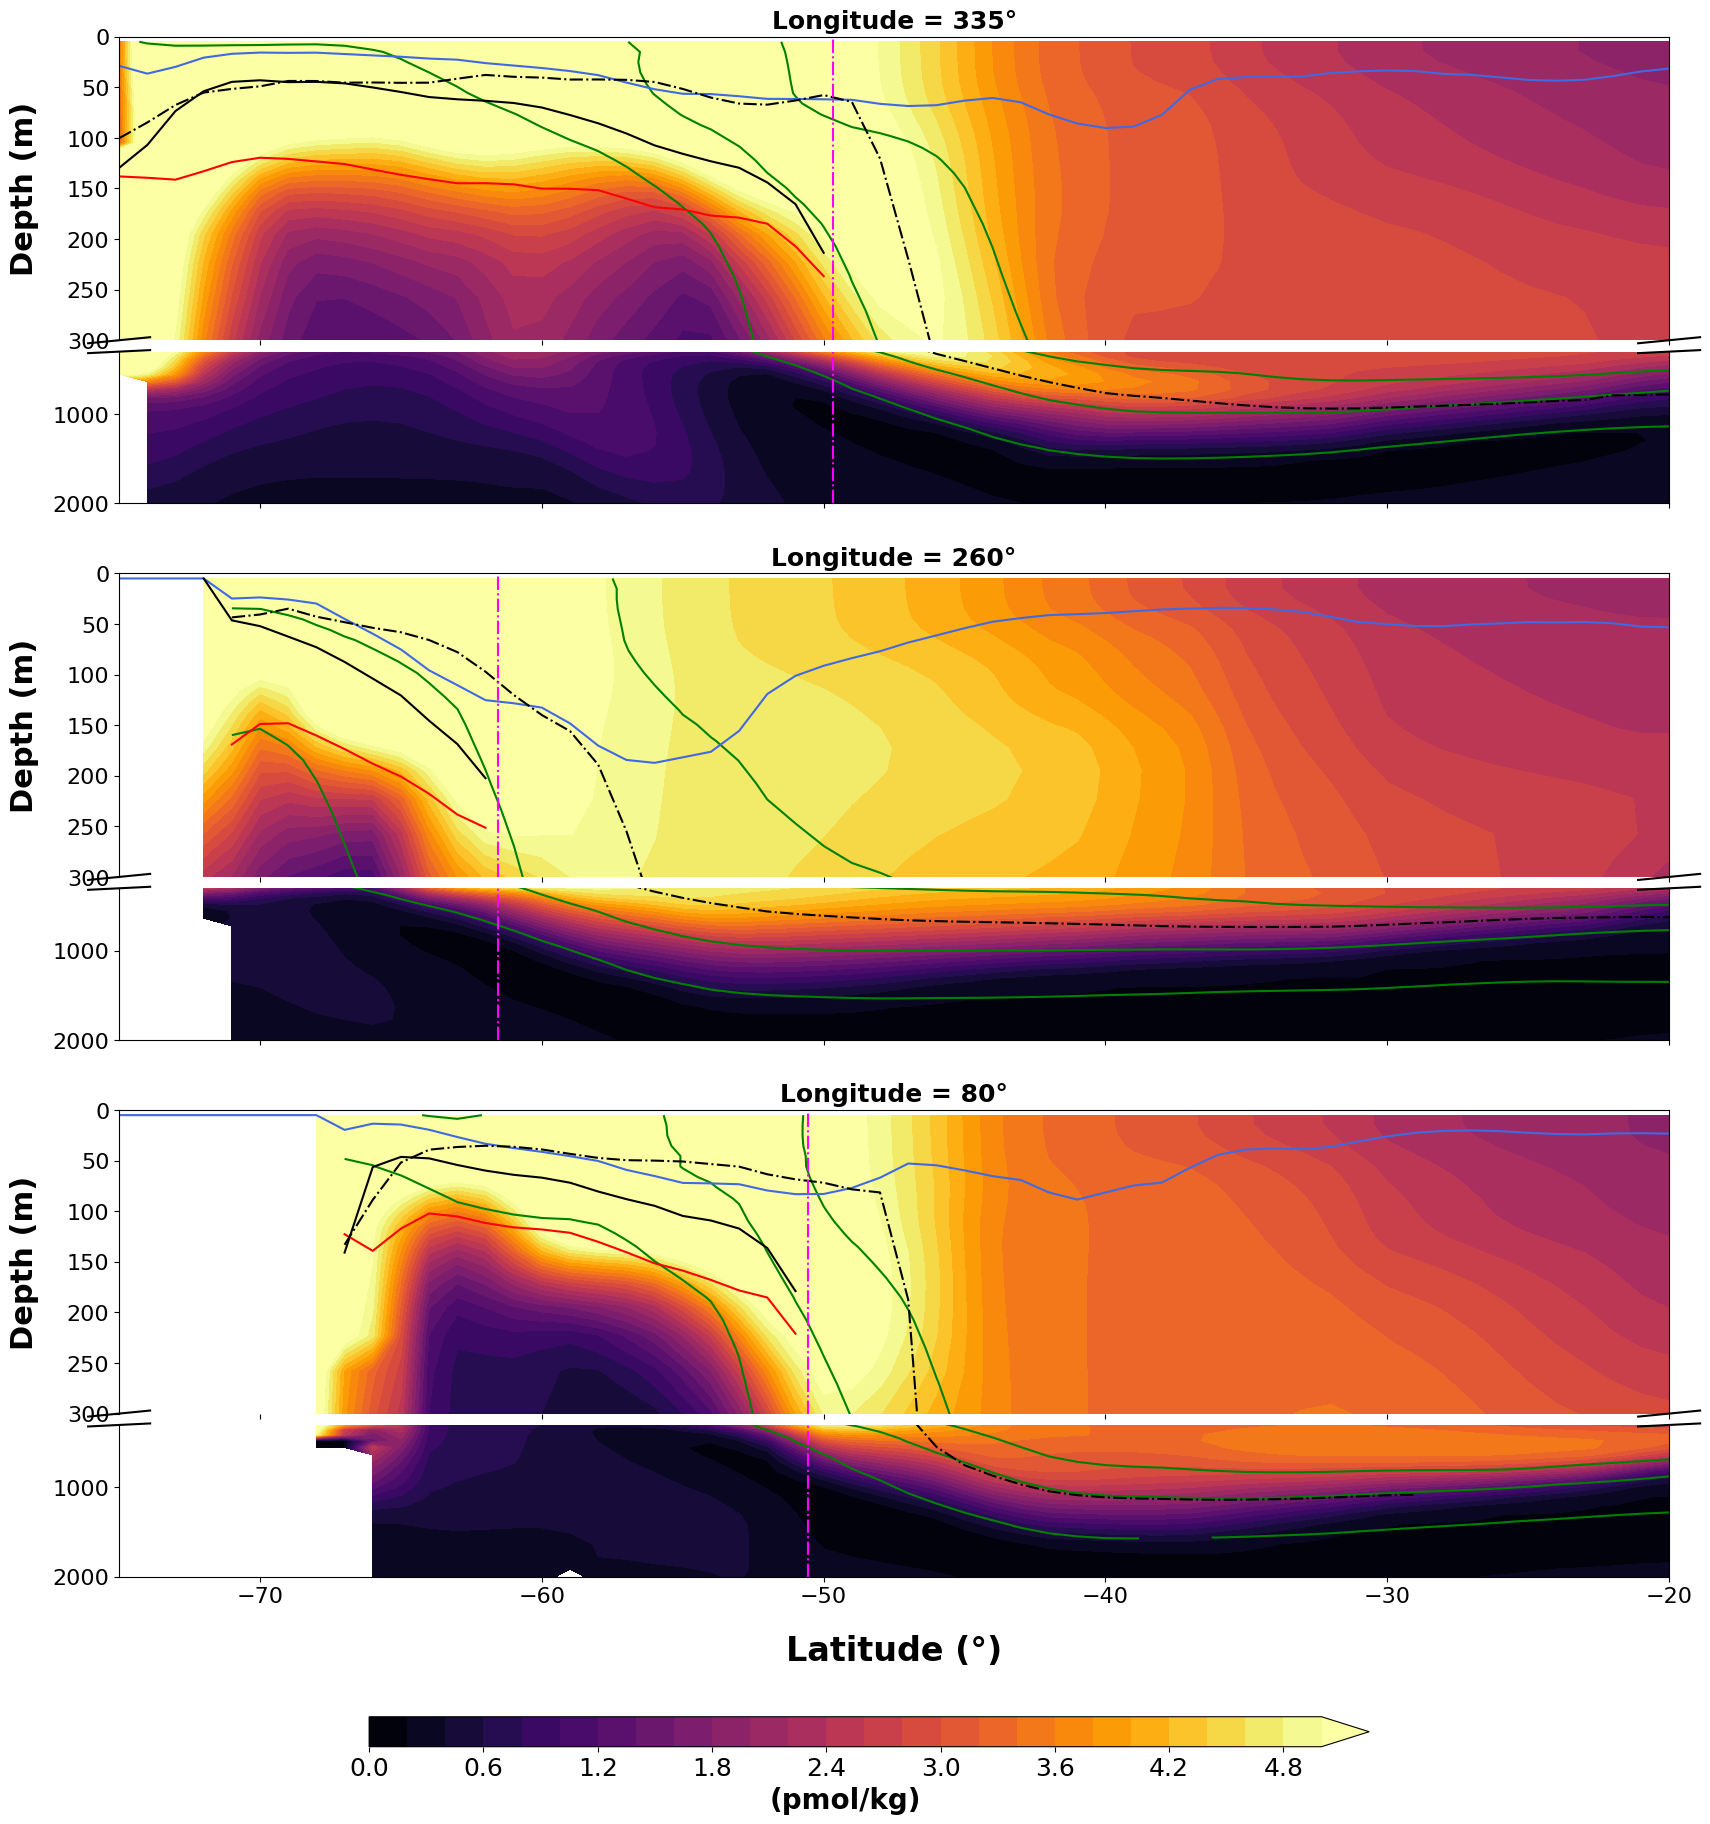

In [30]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import numpy as np

# Longitudes for the three panels
lons = [335, 260, 80]

fig = plt.figure(figsize=(20, 20))  # Increase height for 3 stacked figures
outer_gs = gridspec.GridSpec(3, 1, height_ratios=[1, 1, 1], hspace=0.15)  # Three rows for three longitudes

for i, lon in enumerate(lons):
    # Inner GridSpec for each longitude: two rows (upper & lower depth)
    inner_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[i], height_ratios=[2, 1], hspace=0.05)

    # --- First subplot (shallow) ---
    ax1 = plt.subplot(inner_gs[0])
    cf1 = ax1.contourf(cfc_11['lat'], cfc_11['depth'],
                       cfc_11.sel(lon=lon, method='nearest').mean('time'),
                       np.arange(0,5.1,0.2), cmap='inferno', extend='max')

    ax1.contour(mld_mask['lat'], mld_mask['depth'],
                sig0.sel(lon=lon, method='nearest').mean('time'),
                levels=[26.93, 27.23, 27.53], colors='green')
    ax1.plot(mld['lat'], mld.sel(lon=lon, method='nearest').mean('time'), color='royalblue')
    ax1.plot(mld['lat'], min_temp_depth.sel(lon=lon, method='nearest').mean('time'), color='black')
    ax1.plot(mld['lat'], WW_bot_depth.sel(lon=lon, method='nearest').mean('time'), color='red')
    ax1.plot(mld.sel(lat=slice(-80, -20))['lat'],
             dsdz_depth.sel(lon=lon, method='nearest').sel(lat=slice(-80, -20)).mean('time'),
             linestyle='-.', color='black')
    ax1.axvline(PF_lats.sel(lon=lon, method='nearest'), linestyle='-.', color='magenta')

    ax1.set_ylim(300, 0)
    ax1.set_xlim(-75, -20)
    ax1.spines['bottom'].set_visible(False)
    ax1.tick_params(labelbottom=False, labelsize=16)  # Remove x-ticks
    ax1.set_title(f'Longitude = {lon}°', fontsize=18, fontweight='bold')
    ax1.set_ylabel('Depth (m)', fontsize=22, fontweight='bold', labelpad=20)  # ✅ Added y-label

    # --- Second subplot (deep) ---
    ax2 = plt.subplot(inner_gs[1])
    cf2 = ax2.contourf(cfc_11['lat'], cfc_11['depth'],
                       cfc_11.sel(lon=lon, method='nearest').mean('time'),
                       np.arange(0,5.1,0.2), cmap='inferno', extend='max')

    ax2.contour(mld_mask['lat'], mld_mask['depth'],
                sig0.sel(lon=lon, method='nearest').mean('time'),
                levels=[26.93, 27.23, 27.53], colors='green')
    ax2.plot(mld['lat'], mld.sel(lon=lon, method='nearest').mean('time'), color='yellow')
    ax2.plot(mld['lat'], min_temp_depth.sel(lon=lon, method='nearest').mean('time'), color='black')
    ax2.plot(mld['lat'], WW_bot_depth.sel(lon=lon, method='nearest').mean('time'), color='red')
    ax2.plot(mld.sel(lat=slice(-80, -10))['lat'],
             dsdz_depth.sel(lon=lon, method='nearest').sel(lat=slice(-80, -10)).mean('time'),
             linestyle='-.', color='black')
    ax2.axvline(PF_lats.sel(lon=lon, method='nearest'), linestyle='-.', color='magenta')

    ax2.set_ylim(2000, 300)
    ax2.set_xlim(-75, -20)
    ax2.spines['top'].set_visible(False)
    ax2.tick_params(labelsize=16)
    # ax2.set_ylabel('Depth (m)', fontsize=22, fontweight='bold')  # ✅ Added y-label

    # Add x-ticks and label only for the last longitude
    if i == len(lons) - 1:
        ax2.set_xlabel('Latitude (°)', fontsize=24, fontweight='bold', labelpad=20)
        ax2.tick_params(labelbottom=True)
    else:
        ax2.tick_params(labelbottom=False)

    # Add diagonal break lines between ax1 and ax2
    kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
    ax1.plot((-0.02, +0.02), (-0.01, +0.01), **kwargs)
    ax1.plot((1 - 0.02, 1 + 0.02), (-0.01, +0.01), **kwargs)
    kwargs.update(transform=ax2.transAxes)
    ax2.plot((-0.02, +0.02), (1 - 0.01, 1 + 0.01), **kwargs)
    ax2.plot((1 - 0.02, 1 + 0.02), (1 - 0.01, 1 + 0.01), **kwargs)

# Colorbar for the whole figure
cbar_ax = fig.add_axes([0.25, 0.025, 0.5, 0.015])  # Adjust position
cbar = fig.colorbar(cf2, cax=cbar_ax, orientation='horizontal', extend='max')
cbar.set_label('(pmol/kg)', size=20, fontweight='bold')  # Increase label font size
cbar.ax.tick_params(labelsize=18)  # Increase tick font size

plt.tight_layout(rect=[0, 0.06, 1, 1])
# plt.show()
# plt.savefig('/scratch/kaushik/WORK/INTERMEDIATE_WATER/my_py_scripts/figures/FIG1_cfc11_section.jpg',bbox_inches="tight",dpi=1000)

In [31]:
import xarray as xr
import numpy as np
import pyproj
from scipy.interpolate import griddata
from tqdm import tqdm

# Open merged monthly dataset
ds = xr.open_dataset("/scratch/kaushik/WORK/INTERMEDIATE_WATER/Sea_Ice_data/SIC_mergetime.nc")  # your merged file
x = ds['x'].values
y = ds['y'].values
xx, yy = np.meshgrid(x, y)

# Define projection for NSIDC polar stereographic south
proj_ps = pyproj.Proj("+proj=stere +lat_0=-90 +lat_ts=-70 +lon_0=0 +k=1 +x_0=0 +y_0=0 +a=6378273 +b=6356889.449 +units=m +no_defs")
lon, lat = proj_ps(xx, yy, inverse=True)

# Output grid
lat_out = np.arange(-90, -39.25, 0.25)
lon_out = np.arange(-180, 180, 0.25)
lon_target, lat_target = np.meshgrid(lon_out, lat_out)

# Prepare points for interpolation
points = np.column_stack((lon.flatten(), lat.flatten()))

# Allocate array for output
sic_out = np.full((ds.dims['time'], len(lat_out), len(lon_out)), np.nan)

# Loop over time dimension
for t in tqdm(range(ds.dims['time']), desc="Regridding SIC"):
    sic = ds.cdr_seaice_conc_monthly.isel(time=t).where(lambda v: v != 255) * 0.01
    values = sic.values.flatten()
    sic_interp = griddata(points, values, (lon_target, lat_target), method='linear')
    sic_out[t, :, :] = sic_interp

# Create output dataset
ds_out = xr.Dataset(
    {"sea_ice_conc": (["time", "lat", "lon"], sic_out)},
    coords={"time": ds['time'], "lat": lat_out, "lon": lon_out}
)

# Save to NetCDF
# ds_out.to_netcdf("sic_latlon_0.25deg.nc")
ICEG = ds_out.sea_ice_conc

# --- Compute grid cell area ---
R = 6.371e6  # Earth radius in meters
deg2rad = np.pi / 180
lat_rad = np.deg2rad(ICEG.lat)
dlat = np.abs(np.gradient(ICEG.lat)[0]) * deg2rad
dlon = np.abs(np.gradient(ICEG.lon)[0]) * deg2rad

# Broadcast to 2D
lat2d, lon2d = np.meshgrid(lat_rad, ICEG.lon, indexing='ij')
area = (R**2) * np.cos(lat2d) * dlat * dlon  # shape (lat, lon)
area_da = xr.DataArray(area, coords=[ICEG.lat, ICEG.lon], dims=["lat", "lon"])

ice_area = ICEG*area_da*(1e-6)*100

# ice_area = ice_conc*625

/tmp/ipykernel_299806/2442423378.py:26: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  sic_out = np.full((ds.dims['time'], len(lat_out), len(lon_out)), np.nan)
/tmp/ipykernel_299806/2442423378.py:29: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for t in tqdm(range(ds.dims['time']), desc="Regridding SIC"):
Regridding SIC: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 240/240 [07:06<00:00,  1.78s/it]


## Strip

In [15]:
s_min = salt_along_dsdz
z_min = dsdz_depth

In [16]:
import numpy as np
import xarray as xr

def find_depths_around_smin(salt, depth, s_min, z_min):
    """
    For each (time, lat, lon) column, find the two depths (above and below z_min) 
    where salinity equals 1.001 * s_min.

    Returns:
    depth_above, depth_below: DataArrays with shape (time, lat, lon)
    """
    s_target = s_min * 1.001
    salt_vals = salt.values
    z_vals = depth.values
    s_min_vals = s_min.values
    z_min_vals = z_min.values

    time, nz, lat, lon = salt.shape
    depth_above = np.full((time, lat, lon), np.nan)
    depth_below = np.full((time, lat, lon), np.nan)

    for t in range(time):
        for i in range(lat):
            for j in range(lon):
                s_profile = salt_vals[t, :, i, j]
                if np.any(np.isnan(s_profile)):
                    continue
                
                z_profile = z_vals
                target_sal = s_min_vals[t, i, j] * 1.001
                z0 = z_min_vals[t, i, j]

                # Skip if z0 is nan
                if np.isnan(z0):
                    continue

                # Find index closest to z_min
                k0 = np.argmin(np.abs(z_profile - z0))

                # Search above z_min
                for k in range(k0 - 1, -1, -1):
                    if (s_profile[k] - target_sal) * (s_profile[k + 1] - target_sal) <= 0:
                        z1, z2 = z_profile[k], z_profile[k+1]
                        s1, s2 = s_profile[k], s_profile[k+1]
                        depth_above[t, i, j] = z1 + (target_sal - s1) * (z2 - z1) / (s2 - s1)
                        break

                # Search below z_min
                for k in range(k0, nz - 1):
                    if (s_profile[k] - target_sal) * (s_profile[k + 1] - target_sal) <= 0:
                        z1, z2 = z_profile[k], z_profile[k+1]
                        s1, s2 = s_profile[k], s_profile[k+1]
                        depth_below[t, i, j] = z1 + (target_sal - s1) * (z2 - z1) / (s2 - s1)
                        break

    depth_above_da = xr.DataArray(depth_above, coords=s_min.coords, dims=s_min.dims, name='depth_above')
    depth_below_da = xr.DataArray(depth_below, coords=s_min.coords, dims=s_min.dims, name='depth_below')

    return depth_above_da, depth_below_da

DA,DB = find_depths_around_smin(abs_salt, abs_salt.depth, s_min, z_min)

In [17]:
import xarray as xr
import numpy as np

def interp_salinity_at_zmin(salt, z_min):
    """
    Interpolates salinity along z_min at each (time, lat, lon)
    Inputs:
        salt  : xarray.DataArray, dims (time, depth, lat, lon)
        z_min : xarray.DataArray, dims (time, lat, lon)
    Returns:
        sal_at_zmin : xarray.DataArray, dims (time, lat, lon)
    """
    # Ensure depth is a coordinate
    if "depth" not in salt.coords:
        salt = salt.assign_coords(depth=salt.depth)
    
    depth = salt.depth

    # Define interpolation function
    def interp1d_sal(z, s, z0):
        return np.interp(z0, z, s)

    # Apply vectorized interpolation
    sal_at_zmin = xr.apply_ufunc(
        interp1d_sal,
        depth,
        salt,
        z_min,
        input_core_dims=[["depth"], ["depth"], []],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[salt.dtype],
    )

    sal_at_zmin.name = "salinity_at_zmin"
    return sal_at_zmin

sal_at_zmin = interp_salinity_at_zmin(abs_salt, z_min)

In [18]:
# Convert xarray -> numpy
salt_array = abs_salt.values
z_profile = abs_salt.depth.values
z0_array = z_min.values
s0_array = salt_along_dsdz.values


from numba import njit, prange
import numpy as np

@njit(parallel=True)
def compute_target_depths_4d(salt, z_profile, z0, s0, multiplier=1.0001):
    nt, nz, nlat, nlon = salt.shape

    depth_above = np.full((nt, nlat, nlon), np.nan)
    depth_below = np.full((nt, nlat, nlon), np.nan)

    for t in prange(nt):
        for i in range(nlat):
            for j in range(nlon):
                z0_val = z0[t, i, j]
                s0_val = s0[t, i, j]
                target = s0_val * multiplier

                last_above = -np.inf
                last_below = np.inf

                for k in range(nz - 1):
                    s1 = salt[t, k, i, j]
                    s2 = salt[t, k + 1, i, j]
                    z1 = z_profile[k]
                    z2 = z_profile[k + 1]

                    if (s1 - target) * (s2 - target) <= 0:
                        if s1 != s2:
                            z_cross = z1 + (target - s1) * (z2 - z1) / (s2 - s1)
                        else:
                            z_cross = 0.5 * (z1 + z2)

                        if z_cross < z0_val and z_cross > last_above:
                            last_above = z_cross
                        elif z_cross > z0_val and z_cross < last_below:
                            last_below = z_cross

                if last_above != -np.inf:
                    depth_above[t, i, j] = last_above
                if last_below != np.inf:
                    depth_below[t, i, j] = last_below

    return depth_above, depth_below


depth_above, depth_below = compute_target_depths_4d(salt_array, z_profile, z0_array, s0_array)

import xarray as xr

# Assume sal_at_zmin is your reference DataArray with shape (time, lat, lon)
depth_above_da = xr.DataArray(
    depth_above,
    coords=sal_at_zmin.coords,
    dims=sal_at_zmin.dims,
    name="depth_above_target"
)

depth_below_da = xr.DataArray(
    depth_below,
    coords=sal_at_zmin.coords,
    dims=sal_at_zmin.dims,
    name="depth_below_target"
)

/scratch/kaushik/anaconda3/envs/ocean_old/lib/python3.11/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [19]:
# Convert xarray -> numpy
salt_array = abs_salt.values
z_profile = abs_salt.depth.values
z0_array = z_min.values
s0_array = salt_along_dsdz.values


from numba import njit, prange
import numpy as np

@njit(parallel=True)
def compute_target_depths_4d(salt, z_profile, z0, s0, multiplier=1.0003):
    nt, nz, nlat, nlon = salt.shape

    depth_above = np.full((nt, nlat, nlon), np.nan)
    depth_below = np.full((nt, nlat, nlon), np.nan)

    for t in prange(nt):
        for i in range(nlat):
            for j in range(nlon):
                z0_val = z0[t, i, j]
                s0_val = s0[t, i, j]
                target = s0_val * multiplier

                last_above = -np.inf
                last_below = np.inf

                for k in range(nz - 1):
                    s1 = salt[t, k, i, j]
                    s2 = salt[t, k + 1, i, j]
                    z1 = z_profile[k]
                    z2 = z_profile[k + 1]

                    if (s1 - target) * (s2 - target) <= 0:
                        if s1 != s2:
                            z_cross = z1 + (target - s1) * (z2 - z1) / (s2 - s1)
                        else:
                            z_cross = 0.5 * (z1 + z2)

                        if z_cross < z0_val and z_cross > last_above:
                            last_above = z_cross
                        elif z_cross > z0_val and z_cross < last_below:
                            last_below = z_cross

                if last_above != -np.inf:
                    depth_above[t, i, j] = last_above
                if last_below != np.inf:
                    depth_below[t, i, j] = last_below

    return depth_above, depth_below


depth_above, depth_below = compute_target_depths_4d(salt_array, z_profile, z0_array, s0_array)

import xarray as xr

# Assume sal_at_zmin is your reference DataArray with shape (time, lat, lon)
depth_above_db = xr.DataArray(
    depth_above,
    coords=sal_at_zmin.coords,
    dims=sal_at_zmin.dims,
    name="depth_above_target"
)

depth_below_db = xr.DataArray(
    depth_below,
    coords=sal_at_zmin.coords,
    dims=sal_at_zmin.dims,
    name="depth_below_target"
)

(-80.0, 0.0)

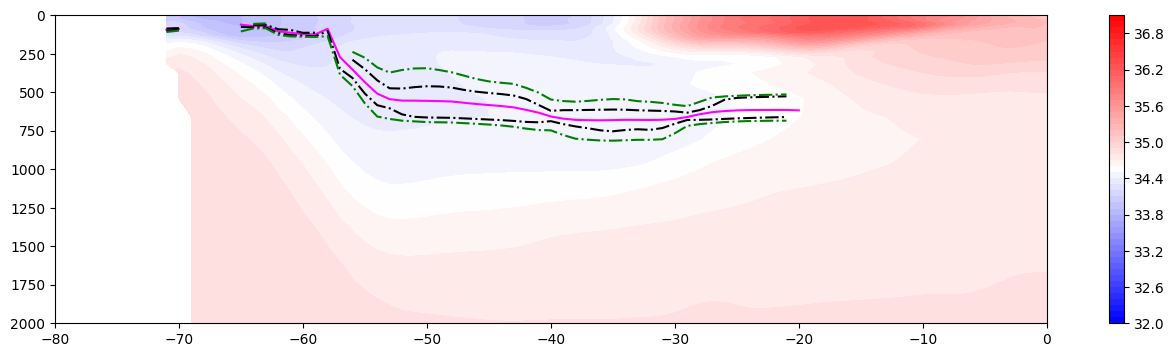

In [20]:
lon = 265; time=150

fig = plt.figure(figsize=(16,4))
# plt.pcolormesh(abs_salt['lat'],abs_salt['depth'],abs_salt.sel(lon=lon,method='nearest').mean(['time']),vmin=32,vmax=37,cmap='bwr')
plt.contourf(abs_salt['lat'],abs_salt['depth'],abs_salt.sel(lon=lon,method='nearest').isel(time=time),np.arange(32,37.1,0.1),cmap='bwr')
plt.colorbar(extend='both')
plt.plot(dsdz_depth['lat'],dsdz_depth.sel(lon=lon).isel(time=time),color='magenta')
plt.plot(dsdz_depth['lat'],depth_above_da.sel(lon=lon).isel(time=time),color='black',linestyle='-.')
plt.plot(dsdz_depth['lat'],depth_below_da.sel(lon=lon).isel(time=time),color='black',linestyle='-.')
plt.plot(dsdz_depth['lat'],depth_above_db.sel(lon=lon).isel(time=time),color='green',linestyle='-.')
plt.plot(dsdz_depth['lat'],depth_below_db.sel(lon=lon).isel(time=time),color='green',linestyle='-.')
# plt.plot(min_depth_interp['lat'],min_depth_interp.sel(lon=lon).mean('time'),color='black',linestyle='-.')
# plt.contour(abs_salt['lat'],abs_salt['depth'],dsdz.sel(lon=lon,method='nearest').mean('time'),levels=[0.],color='black')
plt.ylim(2000,0)
plt.xlim(-80,0)
# plt.savefig('/scratch/kaushik/WORK/INTERMEDIATE_WATER/my_py_scripts/figures/FIG3_section_EPac.jpg',bbox_inches="tight",dpi=1000)

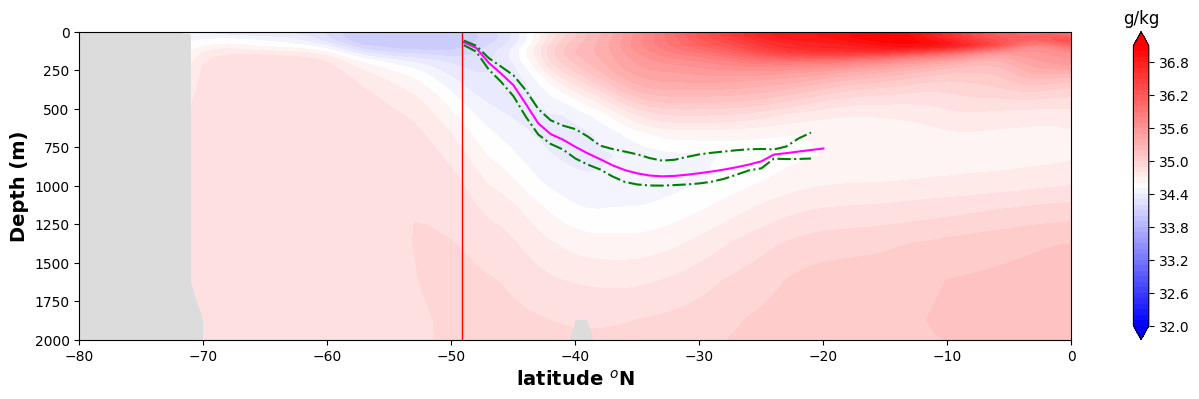

In [22]:
lon = 345; time=150

fig = plt.figure(figsize=(16,4))
# plt.pcolormesh(abs_salt['lat'],abs_salt['depth'],abs_salt.sel(lon=lon,method='nearest').mean(['time']),vmin=32,vmax=37,cmap='bwr')
plt.contourf(abs_salt['lat'],abs_salt['depth'],abs_salt.sel(lon=lon,method='nearest').mean('time'),np.arange(32,37.1,0.1),cmap='bwr',extend='both')
cbar = plt.colorbar(extend='both')
cbar.ax.set_title(r'g/kg', size=12)

amba = dsdz_depth.sel(lat=slice(-49,-20))
plt.plot(amba['lat'],amba.sel(lon=lon).mean('time'),color='magenta')
# plt.plot(dsdz_depth['lat'],depth_above_da.sel(lon=lon).mean('time'),color='black',linestyle='-.')
# plt.plot(dsdz_depth['lat'],depth_below_da.sel(lon=lon).mean('time'),color='black',linestyle='-.')
amba = depth_above_db.sel(lat=slice(-49,-20))
plt.plot(amba['lat'],amba.sel(lon=lon).mean('time'),color='green',linestyle='-.')
amba = depth_below_db.sel(lat=slice(-49,-20))
plt.plot(amba['lat'],amba.sel(lon=lon).mean('time'),color='green',linestyle='-.')
# plt.plot(min_depth_interp['lat'],min_depth_interp.sel(lon=lon).mean('time'),color='black',linestyle='-.')
# plt.contour(abs_salt['lat'],abs_salt['depth'],dsdz.sel(lon=lon,method='nearest').mean('time'),levels=[0.],color='black')
plt.axvline(PF_lats.sel(lon=lon),color='red',linewidth=1)
plt.ylim(2000,0)
plt.xlim(-80,0)
plt.ylabel('Depth (m)',fontsize=14,weight='bold')
plt.xlabel('latitude $^o$N',fontsize=14,weight='bold')
plt.gca().set_facecolor('gainsboro')
plt.savefig('/scratch/kaushik/WORK/INTERMEDIATE_WATER/my_py_scripts/figures/ENSEMBLE_MEANS/final_figure_nc_files/final_nc_files/Supple_Fig_S13.jpg',bbox_inches="tight",dpi=1000)

(2000.0, 0.0)

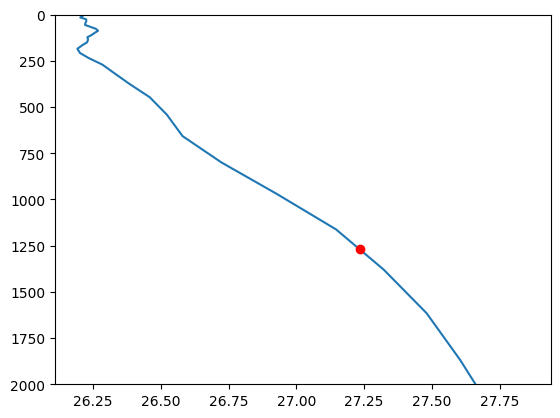

In [39]:
lon = 60; time=150; lat = -40
plt.plot(sig0.sel(lon=lon,lat=lat,method='nearest').isel(time=time),sig0.depth)
plt.plot(sig0_along_dsdz.sel(lon=lon,lat=lat,method='nearest').isel(time=time), 
         dsdz_depth.sel(lon=lon,lat=lat,method='nearest').isel(time=time),'ro')
# plt.plot(dsdz_depth.sel(lon=lon,lat=lat).isel(time=time),color='magenta')
# plt.plot(depth_above_da.sel(lon=lon,lat=lat).isel(time=time),color='black',linestyle='-.')
# plt.plot(depth_below_da.sel(lon=lon,lat=lat).isel(time=time),color='black',linestyle='-.')
# plt.plot(depth_above_db.sel(lon=lon,lat=lat).isel(time=time),color='green',linestyle='-.')
# plt.plot(depth_below_db.sel(lon=lon,lat=lat).isel(time=time),color='green',linestyle='-.')
plt.ylim(2000,0)

In [40]:
abs_salt_str = xr.where(abs_salt.depth<=depth_above_da,np.nan,abs_salt)
abs_salt_strip = xr.where(abs_salt_str.depth>=dsdz_depth,np.nan,abs_salt_str)
del abs_salt_str
abs_salt_strip = abs_salt_strip.transpose('time', 'depth', 'lat', 'lon')

N_sqr_str = xr.where(N_sqr_calc.depth<=depth_above_da,np.nan,N_sqr_calc)
N_sqr_strip = xr.where(N_sqr_str.depth>=dsdz_depth,np.nan,N_sqr_str)
del N_sqr_str
N_sqr_strip = N_sqr_strip.transpose('time', 'depth', 'lat', 'lon')

sig0_str = xr.where(sig0.depth<=depth_above_da,np.nan,sig0)
sig0_strip = xr.where(sig0_str.depth>=dsdz_depth,np.nan,sig0_str)
del sig0_str
sig0_strip = sig0_strip.transpose('time', 'depth', 'lat', 'lon')

import numpy as np
from scipy.interpolate import interp1d
# Ensure PF longitudes are wrapped consistently with EN4 (e.g., 0 to 360)
pf_lons_wrapped = np.mod(pf_lons, 360)
# lon_en4_wrapped = np.mod(lon_en4, 360)
pf_interp = interp1d(pf_lons_wrapped, pf_lats, kind='linear', bounds_error=False, fill_value='extrapolate')
pf_lat_on_en4 = pf_interp(abs_salt.lon.values)
LAT, LON = np.meshgrid(abs_salt.lat.values, abs_salt.lon.values, indexing='ij')
pf_lat_2d = np.tile(pf_lat_on_en4, (LAT.shape[0], 1))
south_of_pf_mask = LAT <= pf_lat_2d
filler = abs_salt_strip[:,:] * (cons_temp[:,:,:,:]*0 + 1)
abs_salt_strip_northPF = filler.where(~south_of_pf_mask)  # ~ to invert the mask
filler = N_sqr_strip[:,:] * (cons_temp[:,:,:,:]*0 + 1)
N_sqr_strip_northPF = filler.where(~south_of_pf_mask)  # ~ to invert the mask
filler = sig0_strip[:,:] * (cons_temp[:,:,:,:]*0 + 1)
sig0_strip_northPF = filler.where(~south_of_pf_mask)  # ~ to invert the mask

In [41]:
abs_salt_strip_northPF = abs_salt_strip_northPF.mean('depth')
N_sqr_strip_northPF = N_sqr_strip_northPF.mean('depth')
sig0_strip_northPF = sig0_strip_northPF.mean('depth')

(-70.0, -30.0)

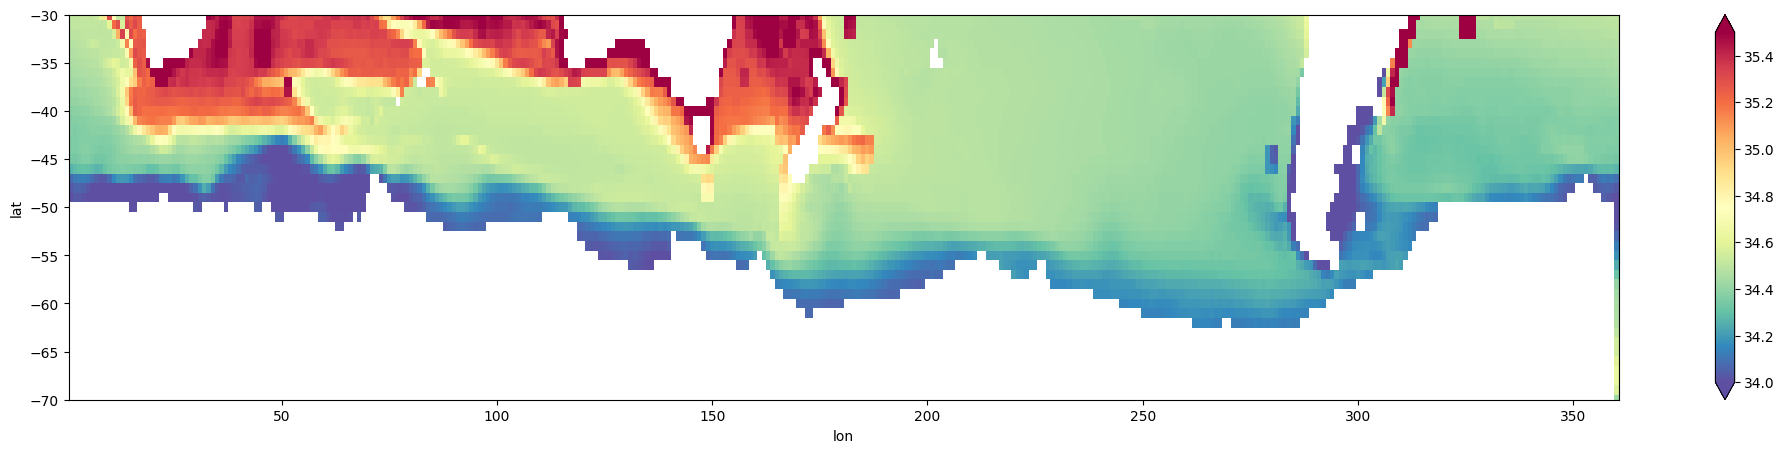

In [56]:
plt.figure(figsize=(25, 5))
abs_salt_strip_northPF.mean('time').plot(vmin=34,vmax=35.5,cmap='Spectral_r')
plt.ylim(-70,-30)

Trend (full):     4.615e-04 per decade (p = 0.234) → Not significant
Trend (≤2015):    -4.955e-03 per decade (p = 0) → Significant
Trend (2016–):    6.629e-03 per decade (p = 1.29e-10) → Significant
Trend (2020–):    -6.065e-03 per decade (p = 0.00433) → Significant


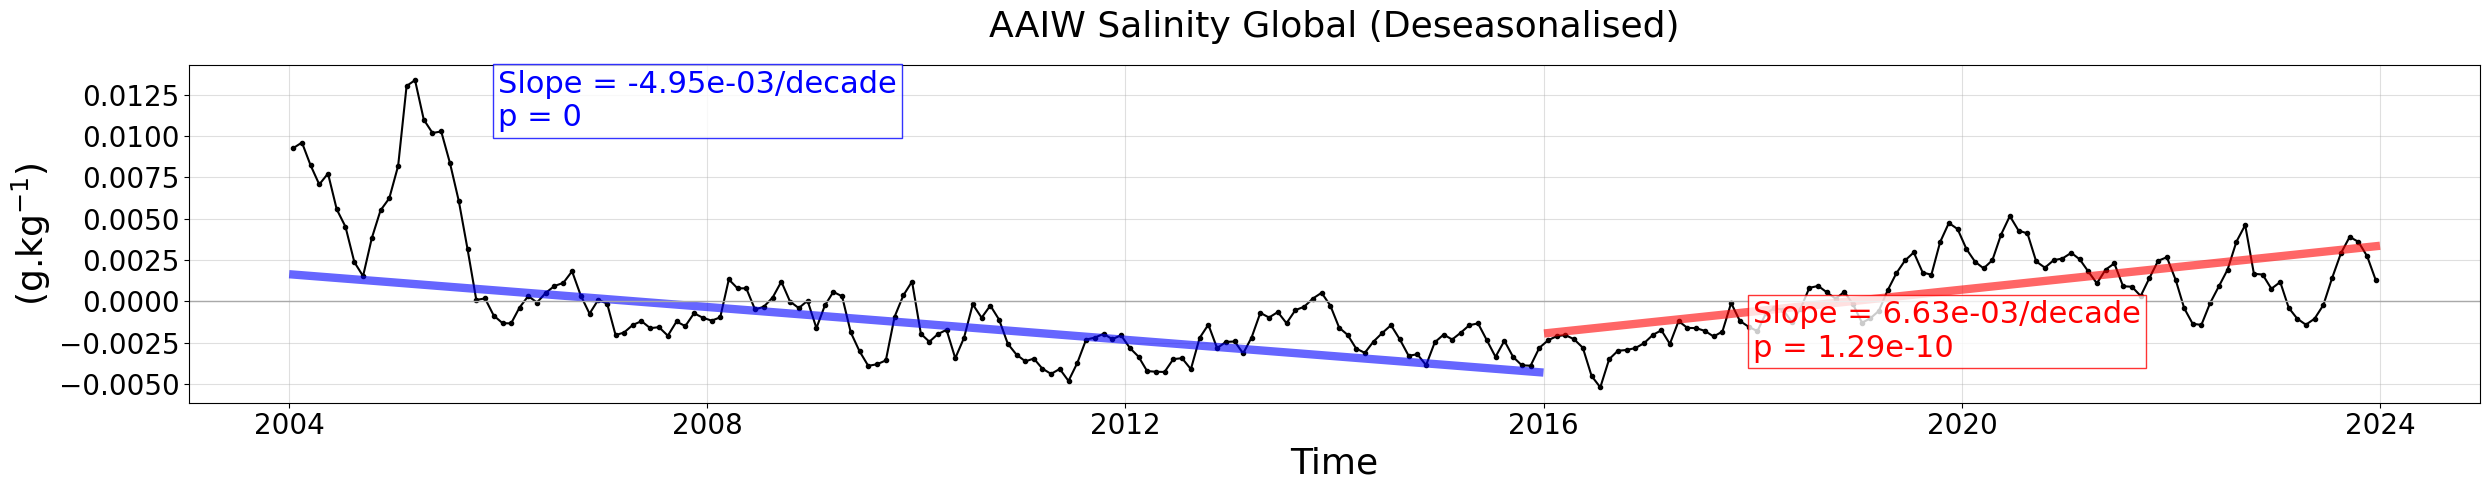

In [63]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pymannkendall as mk

# ts = ice_area.sel(lat=slice(-90, -60), lon=slice(-180, 180)).sum(['lat', 'lon']) * 1e-6
ts = abs_salt_strip_northPF.sel(lon=slice(0,360),lat=slice(-70,-20)).mean(['lat','lon'])
# ts = salt_along_tmin.sel(lon=slice(0,360),lat=slice(-70,-50)).mean(['lat','lon'])

# ============================================================
# DESEASONALISE
# ============================================================
monthly_clim = ts.groupby('time.month').mean('time')
seasonal_removed = ts.groupby('time.month') - monthly_clim

values = seasonal_removed.values.astype(float)
time = pd.to_datetime(seasonal_removed['time'].values)

# ============================================================
# HELPER FUNCTION
# ============================================================
def mann_kendall_with_line(values, mask):
    """
    Apply Mann-Kendall test and Sen's slope to a subset of the series.
    Returns:
        slope_per_month
        p_value
        fitted_line_full_length
    """
    y = values[mask]
    x_local = np.arange(len(y))

    result = mk.original_test(y)
    slope = result.slope          # Sen's slope per time step (month here)
    p_value = result.p
    intercept = np.nanmedian(y) - slope * np.nanmedian(x_local)

    fitted_local = slope * x_local + intercept

    fitted_full = np.full(values.shape, np.nan, dtype=float)
    fitted_full[np.where(mask)[0]] = fitted_local

    return slope, p_value, fitted_full

# ============================================================
# MASKS
# ============================================================
mask_valid = np.isfinite(values)

mask_full = mask_valid

mask_2015 = (time <= np.datetime64('2016-01-01')) & mask_valid

mask_2016 = (
    (time >= np.datetime64('2016-01-01')) &
    (time <= np.datetime64('2024-01-01')) &
    mask_valid
)

mask_2020 = (
    (time >= np.datetime64('2020-01-01')) &
    (time <= np.datetime64('2024-01-01')) &
    mask_valid
)

# ============================================================
# MANN-KENDALL + SEN'S SLOPE
# ============================================================
slope_full, p_full, trend_line_full = mann_kendall_with_line(values, mask_full)
slope_2015, p_2015, trend_line_2015 = mann_kendall_with_line(values, mask_2015)
slope_2016, p_2016, trend_line_2016 = mann_kendall_with_line(values, mask_2016)
slope_2020, p_2020, trend_line_2020 = mann_kendall_with_line(values, mask_2020)

# Convert monthly slope to per decade
slope_full_decade = slope_full * 120
slope_2015_decade = slope_2015 * 120
slope_2016_decade = slope_2016 * 120
slope_2020_decade = slope_2020 * 120

print(f"Trend (full):     {slope_full_decade:.3e} per decade (p = {p_full:.3g}) → {'Significant' if p_full < 0.05 else 'Not significant'}")
print(f"Trend (≤2015):    {slope_2015_decade:.3e} per decade (p = {p_2015:.3g}) → {'Significant' if p_2015 < 0.05 else 'Not significant'}")
print(f"Trend (2016–):    {slope_2016_decade:.3e} per decade (p = {p_2016:.3g}) → {'Significant' if p_2016 < 0.05 else 'Not significant'}")
print(f"Trend (2020–):    {slope_2020_decade:.3e} per decade (p = {p_2020:.3g}) → {'Significant' if p_2020 < 0.05 else 'Not significant'}")

# ============================================================
# PLOT
# ============================================================
plt.figure(figsize=(25, 5))

# Main anomaly series
plt.plot(time, values, marker='o', color='black', linewidth=1.5, markersize=3, label='Anomaly')

# Sen slope lines
plt.plot(time, trend_line_2015, color='blue', linestyle='-', alpha=0.6, linewidth=6, label='Sen slope (≤2015)')
plt.plot(time, trend_line_2016, color='red', linestyle='-', alpha=0.6, linewidth=6, label='Sen slope (2016–)')
# plt.plot(time, trend_line_2020, color='green', linestyle='-', alpha=0.8, linewidth=4, label='Sen slope (2020–)')
# plt.plot(time, trend_line_full, color='purple', linestyle='--', linewidth=3, label='Sen slope (full)')

# Zero line
plt.axhline(0, color='darkgrey', linewidth=1)

# Optional shaded periods
# plt.axvspan(pd.Timestamp('2004-01-01'), pd.Timestamp('2016-01-01'), color='lightblue', alpha=0.2)
# plt.axvspan(pd.Timestamp('2016-01-01'), pd.Timestamp('2020-01-01'), color='lightcoral', alpha=0.2)
# plt.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2024-01-01'), color='lightgreen', alpha=0.2)

# Grid
plt.grid(True, alpha=0.4)

# Labels
plt.title('AAIW Salinity Global (Deseasonalised)', fontsize=26, pad=20)
plt.xlabel("Time", fontsize=26)
plt.ylabel(r"(g.kg$^{-1}$)", fontsize=26)

# Ticks
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# Text positions
ymax = np.nanmax(values)
ymin = np.nanmin(values)
yrange = ymax - ymin

text_x_1 = pd.Timestamp('2006-01-01')
text_x_2 = pd.Timestamp('2018-01-01')

text_y_1 = ymax - 0.15 * yrange
text_y_2 = ymin + 0.10 * yrange

plt.text(
    text_x_1, text_y_1,
    f"Slope = {slope_2015_decade:.2e}/decade\np = {p_2015:.3g}",
    color='blue',
    fontsize=22,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='blue')
)

plt.text(
    text_x_2, text_y_2,
    f"Slope = {slope_2016_decade:.2e}/decade\np = {p_2016:.3g}",
    color='red',
    fontsize=22,
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='red')
)

# Legend
# plt.legend(fontsize=18, loc='best')

plt.tight_layout()
plt.show()

# ============================================================
# SAVE IF NEEDED
# ============================================================
# plt.savefig(
#     '/scratch/kaushik/WORK/INTERMEDIATE_WATER/my_py_scripts/figures/ENSEMBLE_MEANS/FIG2_WW_salinity_timeseries_MK.jpg',
#     bbox_inches="tight",
#     dpi=1000
# )

Computing pre-2016 MK trend...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 64 concurrent workers.
/tmp/ipykernel_299806/65001764.py:40: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_299806/65001764.py:40: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_299806/65001764.py:40: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_299806/65001764.py:40: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_299806/65001764.py:40: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_299806/65001764.py:40: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_299806/65001764.py:40: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_299806/65001764.py:40: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_299806/65001764.py:40: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_299806/65001764.py:40: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_299806/65001764.py:40: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_299806/65001764.py:40: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_299806/65001764.py:4

  slope range : -0.02491 – 0.09817 g/kg/yr
  sig frac    : 2.8%
Computing post-2016 MK trend...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 64 concurrent workers.
/tmp/ipykernel_299806/65001764.py:40: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_299806/65001764.py:40: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_299806/65001764.py:40: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_299806/65001764.py:40: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_299806/65001764.py:40: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_299806/65001764.py:40: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_299806/65001764.py:40: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_299806/65001764.py:40: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_299806/65001764.py:40: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_299806/65001764.py:40: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_299806/65001764.py:40: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_299806/65001764.py:40: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_299806/65001764.py:4

  slope range : -0.07610 – 0.04394 g/kg/yr
  sig frac    : 2.6%


/scratch/kaushik/anaconda3/envs/ocean_old/lib/python3.11/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/scratch/kaushik/anaconda3/envs/ocean_old/lib/python3.11/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/tmp/ipykernel_299806/65001764.py:228: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


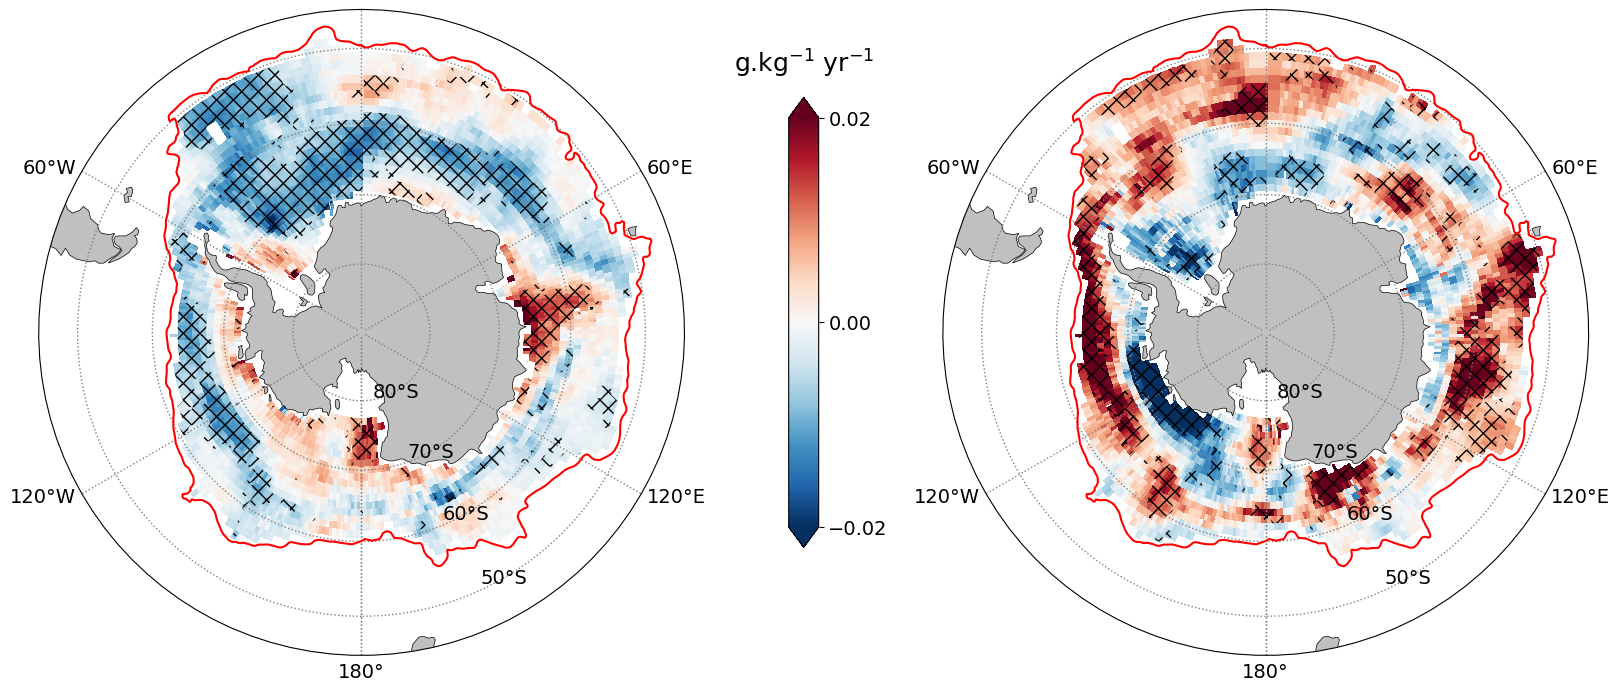

In [65]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeLocator, LatitudeLocator
import pymannkendall as mk
import warnings
from joblib import Parallel, delayed
from scipy.interpolate import interp1d

ww_core_salt = salt_along_tmin

# ============================================================
# POLAR FRONT
# ============================================================
pf_lats        = xr.open_dataset(
    '/scratch/kaushik/WORK/INTERMEDIATE_WATER/ACC_fronts/62985.nc').LatPF
pf_lons        = xr.open_dataset(
    '/scratch/kaushik/WORK/INTERMEDIATE_WATER/ACC_fronts/62985.nc').LonPF
pf_lons_wrapped = np.mod(pf_lons, 360)

# ============================================================
# MK SPATIAL TREND — parallel over latitude rows
# Deseasonalizes monthly data then applies Hamed-Rao MK
# ============================================================
def process_row_mk(j, data_row, min_valid=30):
    """
    data_row : (nt, nlon) monthly raw data
    Returns  : slope_row (nlon,) per year, sig_row (nlon,)
    """
    nt, nlon  = data_row.shape
    slope_row = np.full(nlon, np.nan)
    sig_row   = np.full(nlon, np.nan)

    # Monthly climatology for this row
    clim = np.array([
        np.nanmean(data_row[m::12, k])
        for m in range(12)
        for k in range(nlon)
    ]).reshape(12, nlon)

    # Anomaly
    anom = data_row.copy().astype(float)
    for t in range(nt):
        anom[t] = data_row[t] - clim[t % 12]

    for k in range(nlon):
        v     = anom[:, k]
        valid = np.isfinite(v)
        v_v   = v[valid]
        if len(v_v) < min_valid:
            continue
        if np.std(v_v) < 1e-10:
            continue
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                result = mk.hamed_rao_modification_test(v_v)
            if np.isnan(result.slope) or np.isnan(result.p):
                continue
            slope_row[k] = result.slope * 12   # per year
            if result.p < 0.05:
                sig_row[k] = 1
        except Exception:
            continue

    return j, slope_row, sig_row

def mk_spatial_trend_parallel(data_3d, min_valid=30, n_jobs=-1):
    nt, nlat, nlon = data_3d.shape
    results = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(process_row_mk)(j, data_3d[:, j, :], min_valid)
        for j in range(nlat)
    )
    slope_arr = np.full((nlat, nlon), np.nan)
    sig_arr   = np.full((nlat, nlon), np.nan)
    for j, slope_row, sig_row in results:
        slope_arr[j] = slope_row
        sig_arr[j]   = sig_row
    return slope_arr, sig_arr

# ============================================================
# PRE-2016 : indices 0:144
# ============================================================
print("Computing pre-2016 MK trend...")
data_pre           = ww_core_salt[0:144, :, :].values
nlat, nlon         = data_pre.shape[1], data_pre.shape[2]

slope_pre, sig_pre = mk_spatial_trend_parallel(
    data_pre, min_valid=30, n_jobs=-1)

slope_pre_xr = xr.DataArray(slope_pre,
    coords={'lat': ww_core_salt.lat, 'lon': ww_core_salt.lon},
    dims=['lat','lon'])
sig_pre_xr   = xr.DataArray(sig_pre,
    coords={'lat': ww_core_salt.lat, 'lon': ww_core_salt.lon},
    dims=['lat','lon'])

print(f"  slope range : {np.nanmin(slope_pre):.5f} – "
      f"{np.nanmax(slope_pre):.5f} g/kg/yr")
print(f"  sig frac    : "
      f"{np.nanmean(~np.isnan(sig_pre))*100:.1f}%")

# ============================================================
# POST-2016 : indices 144:240
# ============================================================
print("Computing post-2016 MK trend...")
data_post              = ww_core_salt[144:240, :, :].values

slope_post, sig_post   = mk_spatial_trend_parallel(
    data_post, min_valid=24, n_jobs=-1)

slope_post_xr = xr.DataArray(slope_post,
    coords={'lat': ww_core_salt.lat, 'lon': ww_core_salt.lon},
    dims=['lat','lon'])
sig_post_xr   = xr.DataArray(sig_post,
    coords={'lat': ww_core_salt.lat, 'lon': ww_core_salt.lon},
    dims=['lat','lon'])

print(f"  slope range : {np.nanmin(slope_post):.5f} – "
      f"{np.nanmax(slope_post):.5f} g/kg/yr")
print(f"  sig frac    : "
      f"{np.nanmean(~np.isnan(sig_post))*100:.1f}%")

# ============================================================
# LON WRAPPING
# ============================================================
lon      = ww_core_salt['lon'].values
lat      = ww_core_salt['lat'].values
lon_fixed = np.append(lon, lon[0] + 360)

def wrap_numpy(arr):
    f          = np.array(arr, dtype=float).copy()
    f[:, -3:]  = f[:, -4:-3]
    f[:,  0:3] = f[:,  2:3]
    return np.hstack([f, f[:, 0:1]])

# ============================================================
# PLOT
# ============================================================
def polarCentral_set_latlim(lat_lims, ax):
    ax.set_extent([-180, 180, lat_lims[0], lat_lims[1]],
                  ccrs.PlateCarree())
    theta  = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts  = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(20, 10),
    subplot_kw={'projection': ccrs.SouthPolarStereo(
        central_longitude=0)},
    gridspec_kw={'wspace': 0.4}
)

for ax in [ax1, ax2]:
    ax.add_feature(cfeature.LAND, facecolor='silver')
    ax.coastlines(linewidth=0.5, color='k')
    polarCentral_set_latlim((-90, -45), ax)
    gl = ax.gridlines(
        color='C7', lw=1, ls=':', draw_labels=True,
        rotate_labels=False,
        ylocs=[-80, -70, -60, -50, -40, -30],
        xlocs=[-180, -120, -60, 0, 60, 120, 180]
    )
    gl.top_labels   = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    gl.xlocator     = LongitudeLocator(dms=False)
    gl.ylocator     = LatitudeLocator(dms=False)

# ── Pre-2016 ──
filler1     = wrap_numpy(slope_pre_xr.values)  # per year → already /yr
sig1        = wrap_numpy(np.where(~np.isnan(sig_pre), 1.0, np.nan))

cs1 = ax1.pcolormesh(
    lon_fixed, lat, filler1,
    cmap='RdBu_r', vmin=-0.02, vmax=0.02,
    transform=ccrs.PlateCarree(), zorder=1
)
ax1.contourf(
    lon_fixed, lat, np.nan_to_num(sig1, nan=0),
    hatches=['xx'], levels=[0.5, 1.5],
    alpha=0, transform=ccrs.PlateCarree(), zorder=5
)
ax1.plot(pf_lons_wrapped, pf_lats, color='red',
         linewidth=1.5, transform=ccrs.PlateCarree(), zorder=10)
polarCentral_set_latlim((-90, -45), ax1)
# ax1.set_title('Pre-2016 (2004–2015)\nHamed-Rao MK Sen slope',
#               fontsize=16, pad=12)

# ── Post-2016 ──
filler2     = wrap_numpy(slope_post_xr.values)
sig2        = wrap_numpy(np.where(~np.isnan(sig_post), 1.0, np.nan))

cs2 = ax2.pcolormesh(
    lon_fixed, lat, filler2,
    cmap='RdBu_r', vmin=-0.02, vmax=0.02,
    transform=ccrs.PlateCarree(), zorder=1
)
ax2.contourf(
    lon_fixed, lat, np.nan_to_num(sig2, nan=0),
    hatches=['xx'], levels=[0.5, 1.5],
    alpha=0, transform=ccrs.PlateCarree(), zorder=5
)
ax2.plot(pf_lons_wrapped, pf_lats, color='red',
         linewidth=1.5, transform=ccrs.PlateCarree(), zorder=10)
polarCentral_set_latlim((-90, -45), ax2)
# ax2.set_title('Post-2016 (2016–2023)\nHamed-Rao MK Sen slope',
#               fontsize=16, pad=12)

# ── Colorbar ──
cbar_ax = fig.add_axes([0.50, 0.28, 0.015, 0.45])
cbar    = fig.colorbar(
    cs1, cax=cbar_ax,
    orientation='vertical',
    extend='both',
    ticks=[-0.02, 0, 0.02]
)
cbar.ax.set_title(r'g.kg$^{-1}$ yr$^{-1}$', fontsize=18, pad=18)
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
# plt.savefig(
#     '/scratch/kaushik/WORK/INTERMEDIATE_WATER/my_py_scripts/figures/ENSEMBLE_MEANS/final_figure_nc_files/'
#     'WW_salt_ensemble_trend_pre_post.jpg',
#     bbox_inches='tight', dpi=500)
# plt.show()

Text(34.5, -1.0, 'Winter Water')

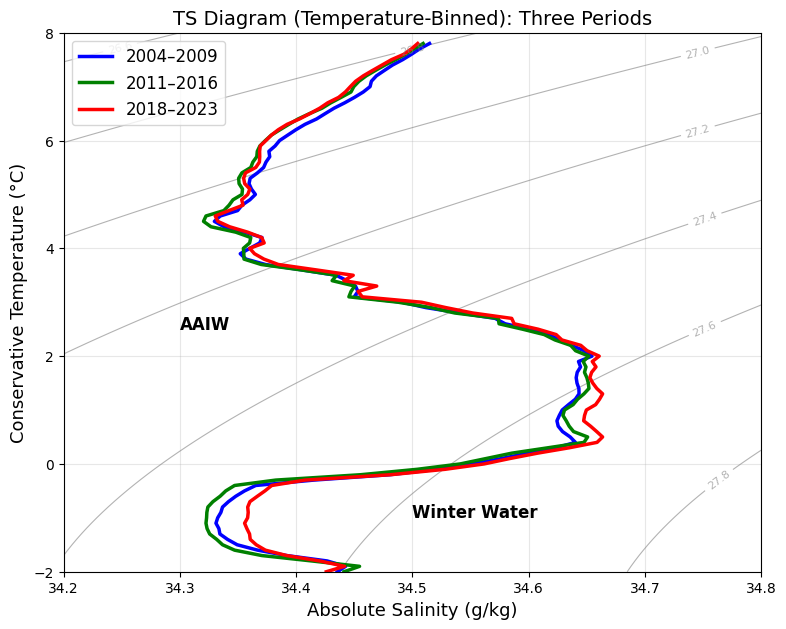

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import gsw
from scipy.interpolate import interp1d

# -----------------------------
# Define time periods
# -----------------------------
period1 = slice('2004-01-01', '2009-12-31')
period2 = slice('2011-01-01', '2016-12-31')
period3 = slice('2018-01-01', '2023-12-31')

# Subset region (adjust as needed)
lat_range = slice(-90, -20)
lon_range = slice(0, 360)
depth_range = slice(0, 2000)

# Select data for each period
S_p1 = abs_salt.sel(time=period1, lat=lat_range, lon=lon_range, depth=depth_range)
T_p1 = cons_temp.sel(time=period1, lat=lat_range, lon=lon_range, depth=depth_range)

S_p2 = abs_salt.sel(time=period2, lat=lat_range, lon=lon_range, depth=depth_range)
T_p2 = cons_temp.sel(time=period2, lat=lat_range, lon=lon_range, depth=depth_range)

S_p3 = abs_salt.sel(time=period3, lat=lat_range, lon=lon_range, depth=depth_range)
T_p3 = cons_temp.sel(time=period3, lat=lat_range, lon=lon_range, depth=depth_range)

# Convert to 1D arrays and remove NaNs
def flatten_and_mask(S, T):
    S_flat = S.values.flatten()
    T_flat = T.values.flatten()
    mask = ~np.isnan(S_flat) & ~np.isnan(T_flat)
    return S_flat[mask], T_flat[mask]

S1, T1 = flatten_and_mask(S_p1, T_p1)
S2, T2 = flatten_and_mask(S_p2, T_p2)
S3, T3 = flatten_and_mask(S_p3, T_p3)

# -----------------------------
# Create bins for temperature
# -----------------------------
temp_bins = np.arange(-2, 8, 0.1)

def bin_mean(x, y, bins):
    idx = np.digitize(x, bins)
    y_mean = [np.nanmean(y[idx == i]) for i in range(1, len(bins))]
    return bins[:-1], np.array(y_mean)

# Apply binning
temp1, sal1_mean = bin_mean(T1, S1, temp_bins)
temp2, sal2_mean = bin_mean(T2, S2, temp_bins)
temp3, sal3_mean = bin_mean(T3, S3, temp_bins)

# -----------------------------
# Compute density grid for contours
# -----------------------------
s_grid = np.linspace(34.2, 34.8, 100)
t_grid = np.linspace(-2, 8, 100)
Sg, Tg = np.meshgrid(s_grid, t_grid)
sigma0_grid = gsw.sigma0(Sg, Tg)

# -----------------------------
# Plot TS diagram
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 7))

# Density contours
cs = ax.contour(Sg, Tg, sigma0_grid, levels=np.arange(26.0, 28.5, 0.2), colors='gray', linewidths=0.8, alpha=0.6)
ax.clabel(cs, inline=True, fontsize=8, fmt='%.1f')

# TS lines
ax.plot(sal1_mean, temp1, color='blue', lw=2.5, label='2004–2009')
ax.plot(sal2_mean, temp2, color='green', lw=2.5, label='2011–2016')
ax.plot(sal3_mean, temp3, color='red', lw=2.5, label='2018–2023')

# Labels and aesthetics
ax.set_xlabel('Absolute Salinity (g/kg)', fontsize=13)
ax.set_ylabel('Conservative Temperature (°C)', fontsize=13)
ax.set_title('TS Diagram (Temperature-Binned): Three Periods', fontsize=14)
ax.grid(alpha=0.3)
ax.legend(fontsize=12)

# Annotate water masses
ax.text(34.3, 2.5, 'AAIW', fontsize=12, color='black', fontweight='bold')
ax.text(34.5, -1.0, 'Winter Water', fontsize=12, color='black', fontweight='bold')

# plt.show()
# plt.savefig('/scratch/kaushik/WORK/INTERMEDIATE_WATER/my_py_scripts/figures/FIG4_TS_charts_three_periods.jpg',bbox_inches="tight",dpi=1000)